<style>
:root { --navy:#102A43; --blue:#2563EB; --teal:#0F9D91; --slate:#475569; --paper:#F8FAFC; }
.hero {padding:34px 38px;border-radius:20px;background:linear-gradient(125deg,#102A43,#2563EB 62%,#0F9D91);color:white;box-shadow:0 14px 30px #0f172a26;margin:8px 0 24px}
.hero h1{font-size:2.35rem;margin:0 0 8px}.hero p{font-size:1.05rem;opacity:.94;margin:5px 0}
.tag{display:inline-block;padding:5px 10px;margin:10px 5px 0 0;background:#ffffff20;border:1px solid #ffffff55;border-radius:999px}
.section{padding:18px 24px;border-left:6px solid var(--teal);background:linear-gradient(90deg,#ECFEFF,#F8FAFC);border-radius:8px;margin:26px 0 14px}
.section h2{margin:0;color:var(--navy)}
.note{padding:14px 18px;border-radius:10px;background:#EFF6FF;border:1px solid #BFDBFE;color:#1E3A8A}
.warn{padding:14px 18px;border-radius:10px;background:#FFF7ED;border:1px solid #FED7AA;color:#9A3412}
table.dataframe{font-size:13px;border-collapse:collapse} table.dataframe th{background:#102A43;color:white;padding:7px} table.dataframe td{padding:6px;border-bottom:1px solid #E2E8F0}
</style>
<div class="hero">
  <h1>Laboratorio 6 · Analítica de Redes Sociales</h1>
  <p>Participación, comunidades, puentes y sentimiento en YouTube</p>
  <p><b>CC3084 · Data Science · Sección 10 · Grupo 1</b></p>
  <span class="tag">293 videos</span><span class="tag">406 comentarios</span><span class="tag">332 autores</span><span class="tag">Entrega final</span>
</div>

**Integrantes:** Jorge Gabriel Palacios Sales (231385) · Pablo Daniel Barillas Moreno (22193) · Roberto Emiliano Otoniel (23968)  
**Universidad del Valle de Guatemala · Segundo semestre 2026**

Este notebook es el punto de entrada reproducible de la entrega. La primera celda de código ejecuta todo el pipeline; las siguientes celdas leen y explican los productos generados.

In [1]:
from pathlib import Path
import json, subprocess, sys
import pandas as pd
from IPython.display import HTML, Image, Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "scripts" / "run_final.py").exists(), "Ejecute el notebook dentro del repositorio."

completed = subprocess.run(
    [sys.executable, str(ROOT / "scripts" / "run_final.py")],
    cwd=ROOT, check=True, capture_output=True, text=True, encoding="utf-8", errors="replace"
)
print(completed.stdout)
TABLES, FIGURES = ROOT / "outputs" / "tables", ROOT / "outputs" / "figures"
summary = json.loads((TABLES / "resumen_final.json").read_text(encoding="utf-8"))

Etapas base y estructural regeneradas.

Laboratorio 6 final regenerado correctamente
Sentimiento: negativo | confianza media=0.818
R�brica documentada: 100/100



In [2]:
display(HTML('''
<style>
.cards{display:grid;grid-template-columns:repeat(4,minmax(120px,1fr));gap:12px;margin:12px 0 20px}
.card{padding:16px;border-radius:12px;background:white;border:1px solid #CBD5E1;box-shadow:0 5px 15px #0f172a12}
.card b{font-size:1.6rem;color:#2563EB;display:block}.card span{color:#475569}
</style>
<div class='cards'>
 <div class='card'><b>293</b><span>videos</span></div><div class='card'><b>406</b><span>comentarios</span></div>
 <div class='card'><b>332</b><span>autores</span></div><div class='card'><b>100 %</b><span>integración</span></div>
</div>'''))

<div class="section"><h2>1–2 · Integración, calidad y preprocesamiento</h2></div>

Los archivos se detectan por contenido y no solo por extensión, por lo que el cargador acepta CSV y Excel. En videos, cada fila es un video y `video_id` es la llave primaria; en comentarios, cada fila es un comentario principal y `comment_id` es la llave primaria. `video_id` actúa como llave foránea. `channel_id` identifica al canal propietario y `author_channel_id` al autor; `category` describe el video y `source_query` documenta el muestreo.

Se auditan duplicados, ausencias, tipos, constantes, atípicos por IQR y consistencia de IDs/nombres/handles. Los conteos admiten comas, espacios y sufijos `K`, `mil`, `M`, `millón/millones`; los vacíos descriptivos pasan a cero y los valores imposibles a faltante. Para frecuencias se usa `texto_limpio`; para sentimiento se conserva `texto_original` para no perder negaciones, emojis ni puntuación.

In [3]:
display(pd.read_csv(TABLES / "formatos_detectados.csv"))
display(pd.read_csv(TABLES / "calidad_resumen.csv"))
display(pd.read_csv(TABLES / "integracion_resumen.csv"))
display(pd.read_csv(TABLES / "tratamiento_variables.csv").head(8))

,dataset,archivo,extension,formato_real
0,videos,youtube_videos.csv,.csv,csv
1,comments,youtube_comments.csv,.csv,csv


,dataset,metrica,valor
0,videos_original,filas,293
1,videos_original,columnas,20
2,videos_original,celdas_faltantes,77
3,videos_original,filas_duplicadas,0
4,videos_original,video_id_faltantes,0
5,videos_original,video_id_duplicados,0
6,videos_original,variables_constantes,ninguna
7,videos_original,atipicos_iqr,view_count:49
8,comments_original,filas,406
9,comments_original,columnas,17


,metrica,valor
0,comentarios_totales,406.0
1,comentarios_asociados,406.0
2,comentarios_sin_video,0.0
3,porcentaje_asociado,100.0
4,videos_con_comentarios,19.0
5,videos_sin_comentarios,274.0


,variable,tratamiento,justificacion
0,viewer_rating,Excluir,100 % faltante; no aporta información.
1,is_pinned,"Conservar para auditoría, no modelar",Es constante (False).
2,published_time/published_text,Describir con cautela,Tiempo relativo dependiente de la fecha de rec...
3,reply_count,Conteo descriptivo,No identifica autores de respuestas y no gener...
4,source_query,Variable de muestreo,"Explica recolección, no necesariamente el tema..."
5,nombres/handles,Solo etiquetas,Los nodos se identifican mediante IDs estables.
6,lematización,No aplicada en el avance,Sin un modelo morfosintáctico español validado...
7,emojis,"Retirados de texto_limpio, conservados en text...",Se preservan para sentimiento en la fase final.


<div class="note"><b>Decisión de red:</b> <code>reply_count</code> solo expresa cuántas respuestas recibió un comentario. Como no identifica a quienes respondieron, no se fabrican aristas autor–autor.</div>

<div class="section"><h2>3 · Exploración de participación y contenido</h2></div>

Se cuantifica participación por video, canal y autor; concentración; asociación entre visualizaciones y comentarios; y frecuencias de unigramas, bigramas y hashtags.

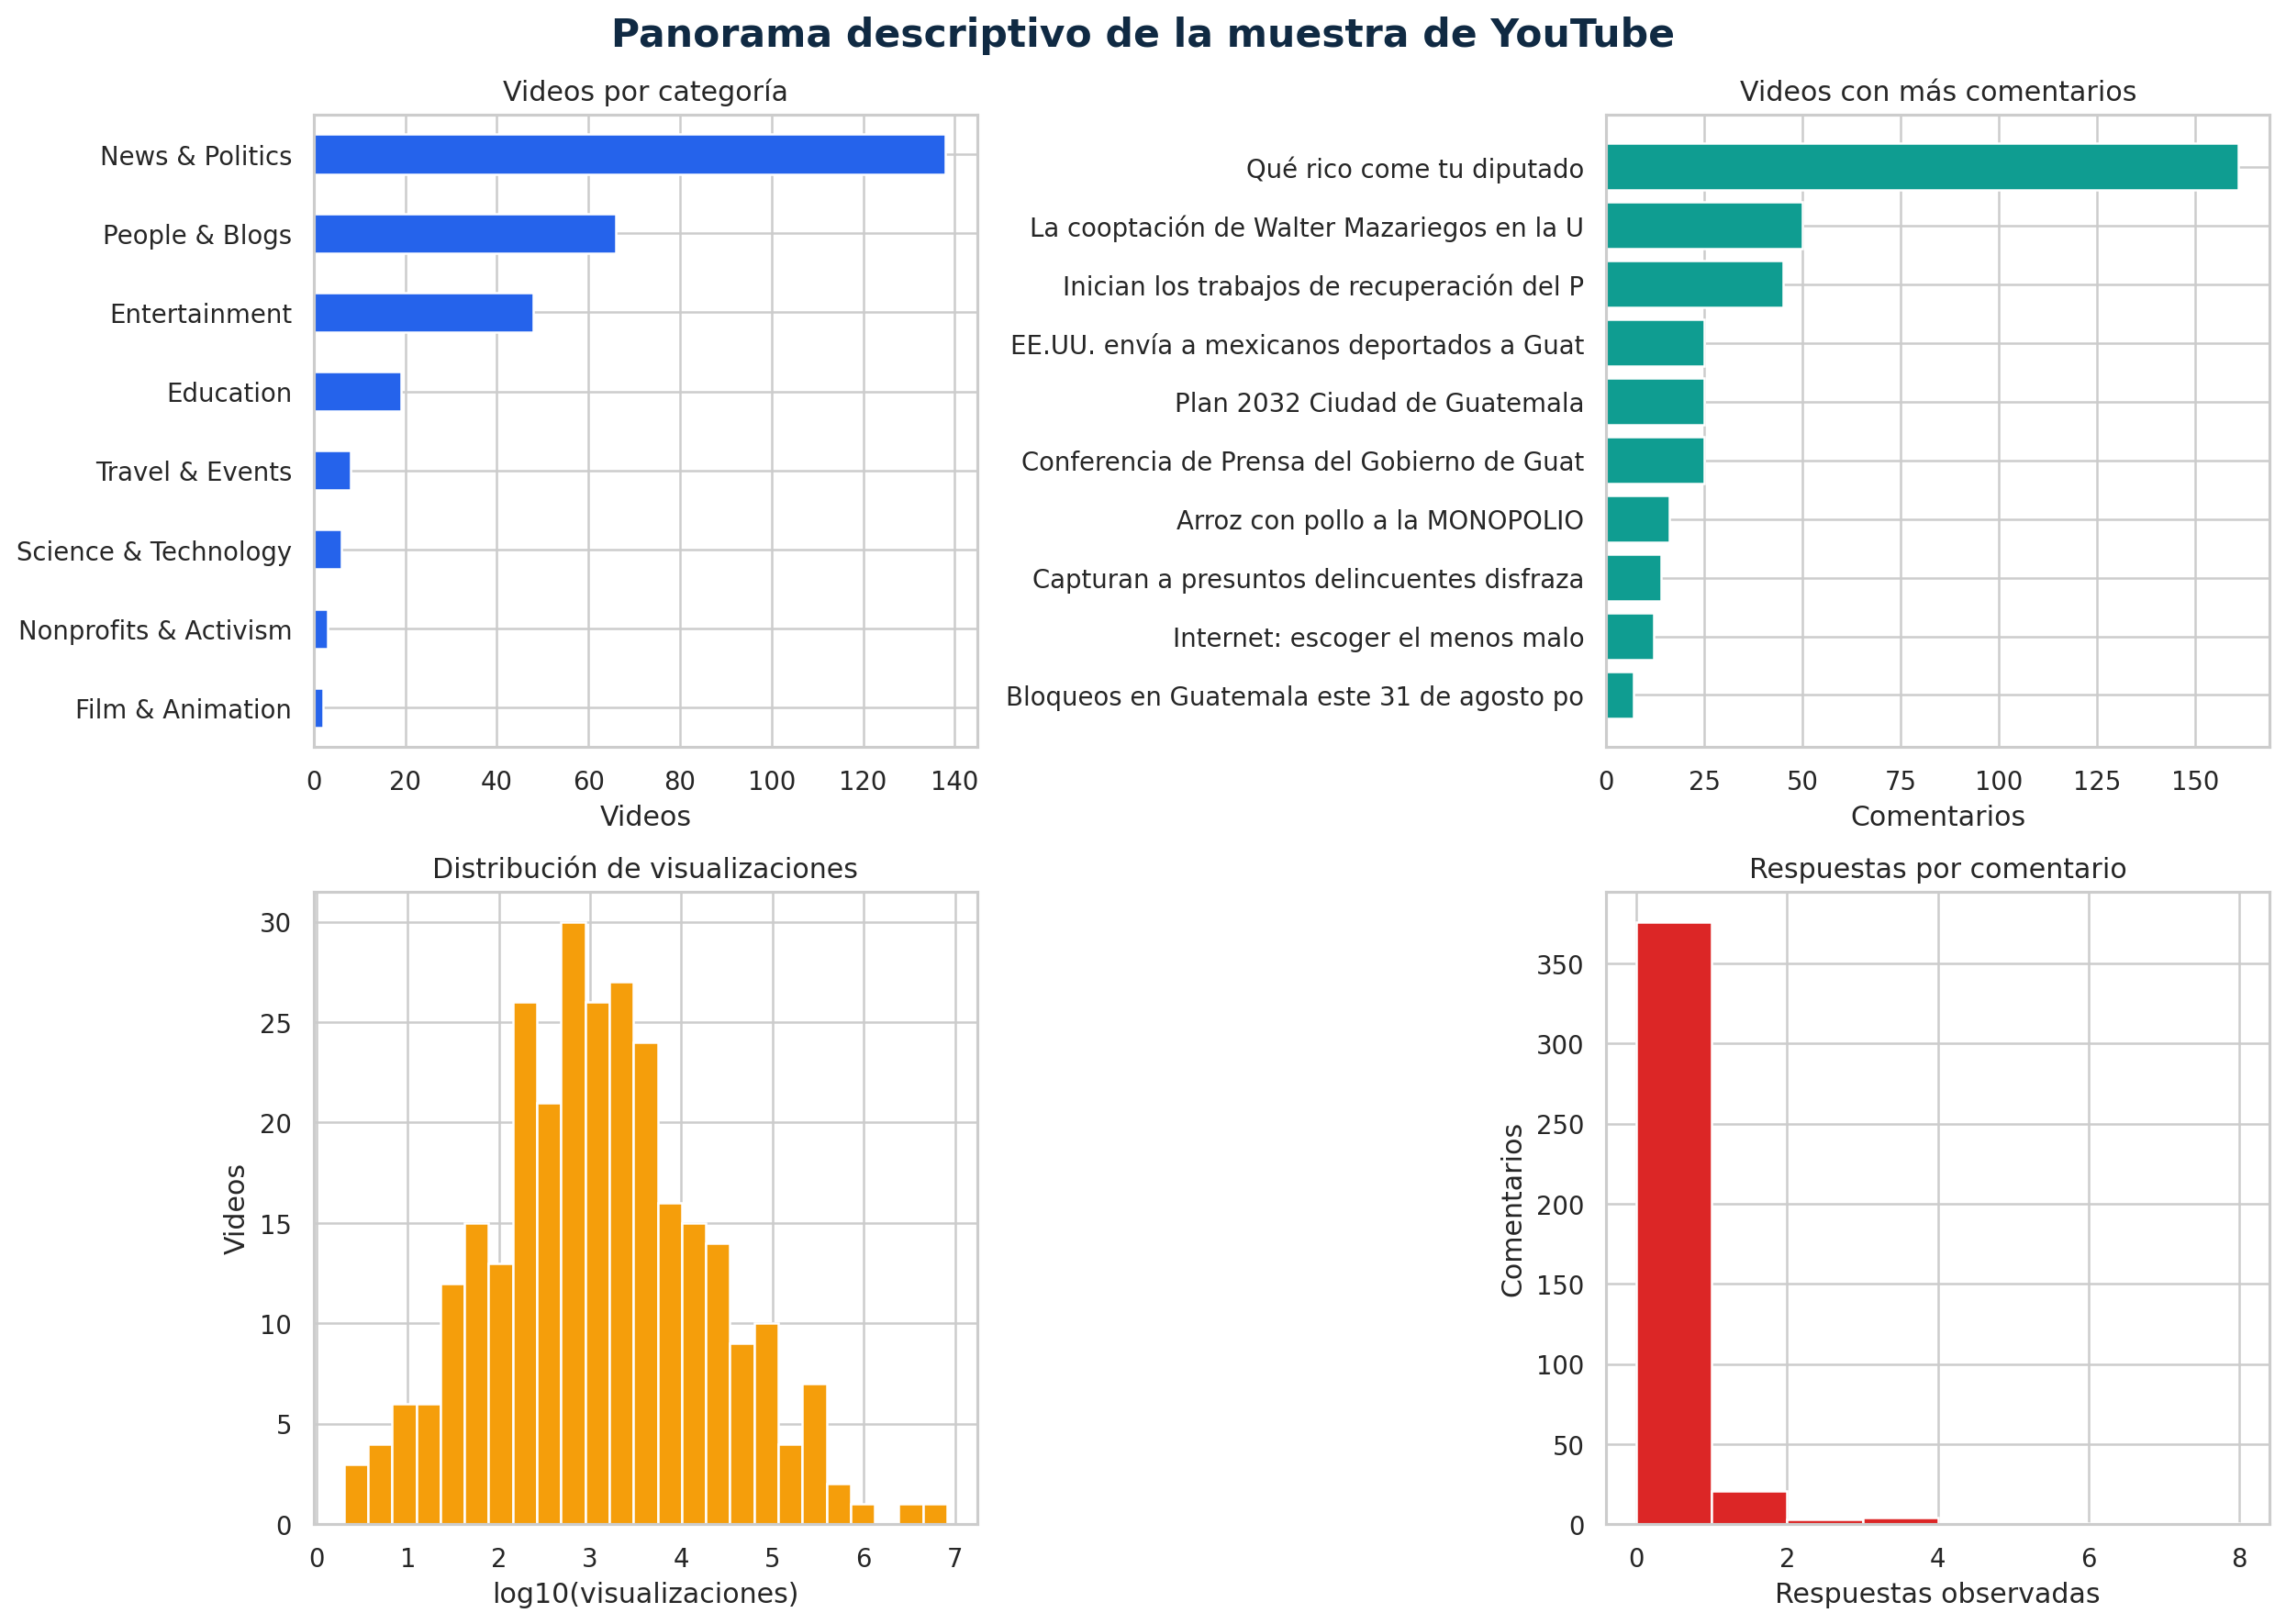

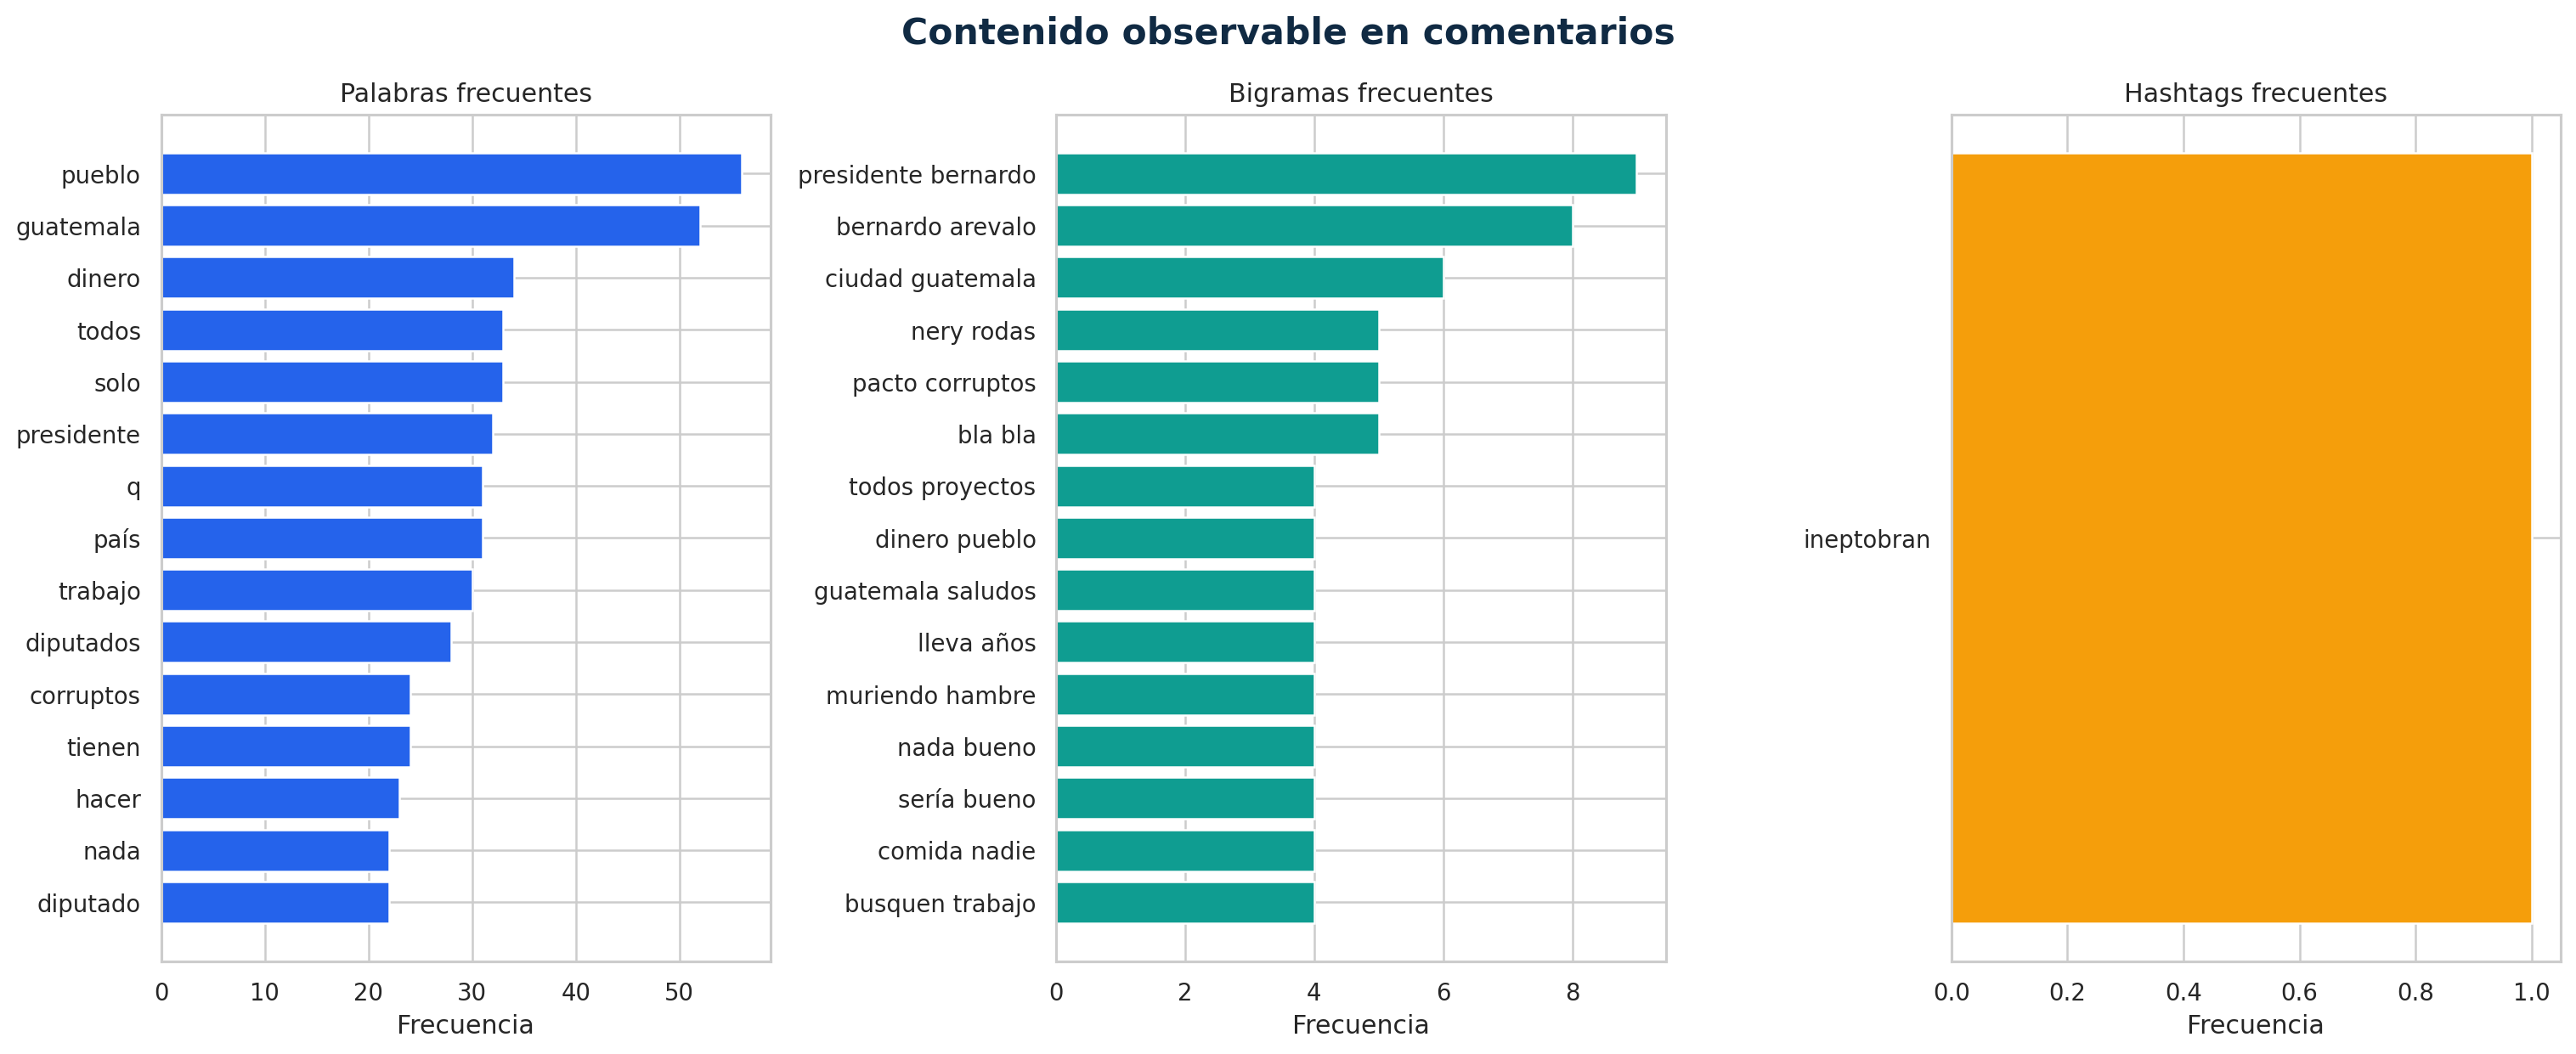

,unidad,top_n,comentarios_acumulados,participacion_pct
0,video,1,161,39.655172
1,video,3,256,63.054187
2,video,5,306,75.369458
3,video,10,380,93.596059
4,canal,1,256,63.054187
5,canal,3,351,86.453202
6,canal,5,390,96.059113
7,canal,10,406,100.000000


In [4]:
display(Image(filename=str(FIGURES / "eda_panorama.png"), width=900))
display(Image(filename=str(FIGURES / "frecuencias_contenido.png"), width=900))
display(pd.read_csv(TABLES / "concentracion_participacion.csv"))

El top 5 de videos reúne **75.4 %** de los comentarios. En los 293 videos, vistas y comentarios presentan asociación débil (Spearman ρ=0.080, p=0.170); al restringir a los 19 videos con comentarios, ρ=0.811 (p<0.001). El contraste evidencia un sesgo de cobertura y no debe interpretarse como causalidad ni popularidad universal.

<div class="section"><h2>4–5 · Red bipartita y proyecciones</h2></div>

La red bipartita conecta autores con videos comentados. La proyección autor–autor representa copresencia en uno o más videos; la proyección video–video conecta videos con al menos un autor compartido. El peso conserva la cantidad de participaciones compartidas.

,red,nodos,aristas,nodos_activos,nodos_aislados,densidad,grado_medio,grado_mediano,grado_maximo,componentes,componente_mayor,componente_mayor_pct,transitividad,clustering_medio,cohesion_nodos_lcc,cohesion_aristas_lcc,diametro_lcc
0,bipartita_autor_video,625,343,351,274,0.001759,1.097600,1.0,128,284,286,45.760000,0.000000,0.000000,1,1,12
1,proyeccion_autores,332,10732,328,4,0.195319,64.650602,48.0,183,10,276,83.132530,0.984025,0.486240,1,5,6
2,proyeccion_videos,293,11,10,283,0.000257,0.075085,0.0,4,284,10,3.412969,0.315789,0.006092,1,1,5


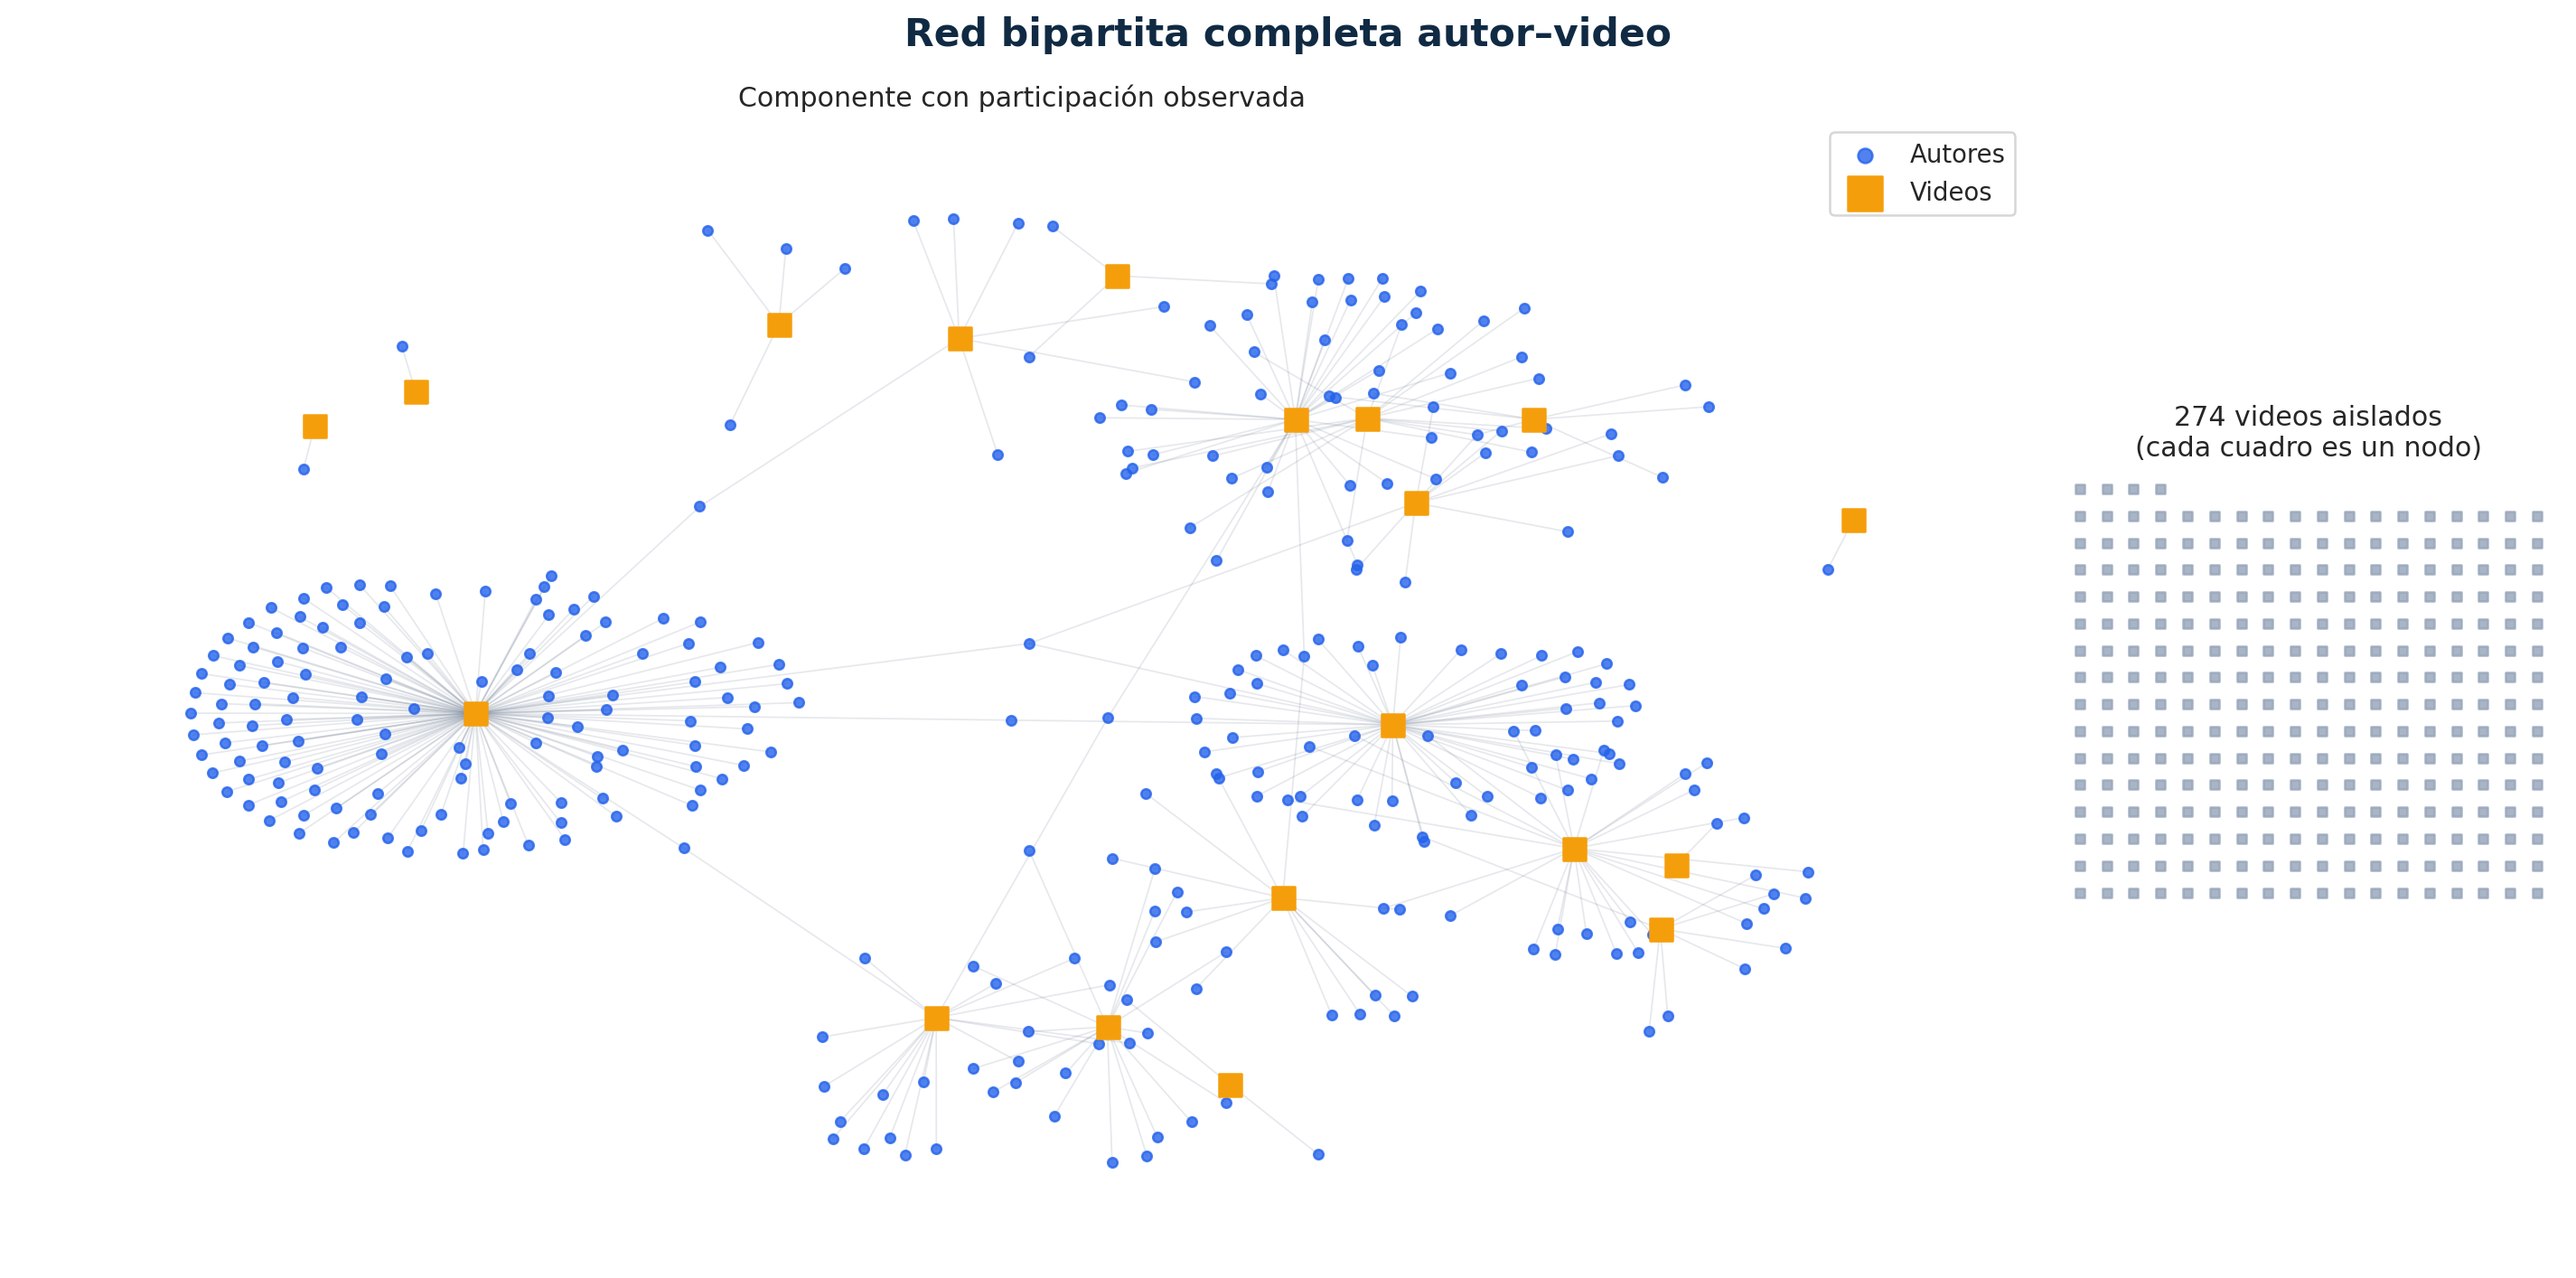

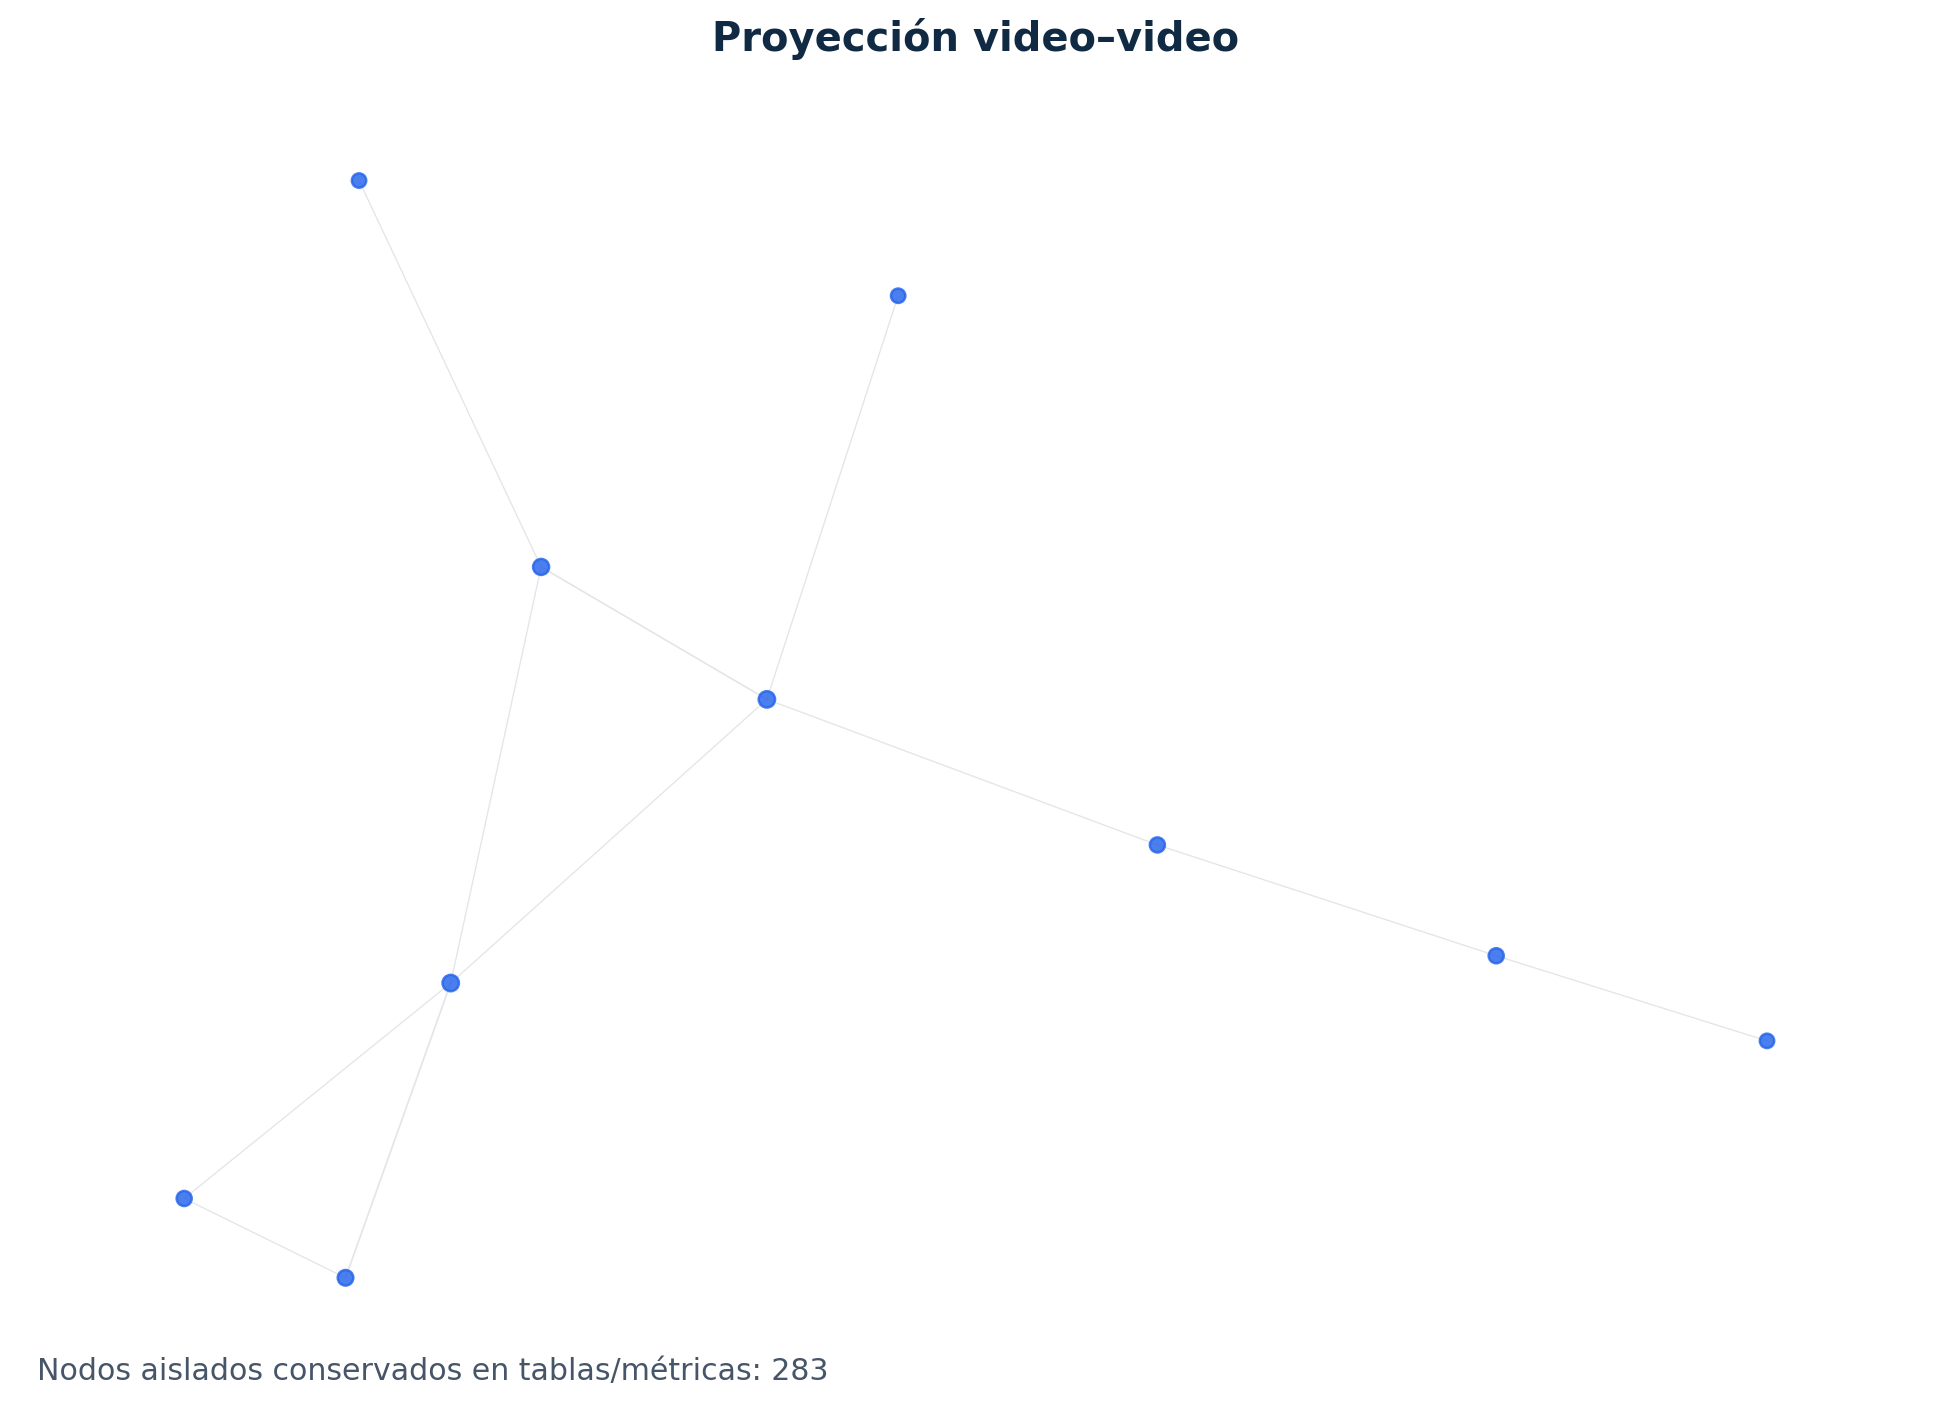

In [5]:
display(pd.read_csv(TABLES / "metricas_redes.csv"))
display(Image(filename=str(FIGURES / "red_bipartita_completa.png"), width=920))
display(Image(filename=str(FIGURES / "proyeccion_videos.png"), width=860))

<div class="section"><h2>6 · Topología, componentes y fragmentación</h2></div>

Se reportan tamaño, aristas, densidad, componentes, componente mayor, grados y periferia. La remoción se usa como experimento estructural: compara componentes y fragmentación antes y después de retirar candidatos centrales.

,red,componente,nodos
0,bipartita_autor_video,1,286
1,bipartita_autor_video,2,26
2,bipartita_autor_video,3,19
3,bipartita_autor_video,4,5
4,bipartita_autor_video,5,4
284,proyeccion_autores,1,276
285,proyeccion_autores,2,25
286,proyeccion_autores,3,18
287,proyeccion_autores,4,4
288,proyeccion_autores,5,3


,red,node,node_id,node_type,label,grado,aristas_eliminadas,componentes_antes,componentes_despues,componentes_nuevos,componente_mayor_antes,componente_mayor_despues,cambio_componente_mayor_pct,fragmentacion_antes,fragmentacion_despues,incremento_fragmentacion,es_punto_articulacion
0,proyeccion_autores,author::UCHTGCgY2l-DQJIvlA_cpa_Q,UCHTGCgY2l-DQJIvlA_cpa_Q,author,@virgiliogarcia3039,145,145,10,11,1,276,214,-22.463768,0.301694,0.540712,0.239019,True
1,proyeccion_autores,author::UCzZ6dDCEsLMXbc5pCFXIprw,UCzZ6dDCEsLMXbc5pCFXIprw,author,@josegil3813,49,49,10,11,1,276,232,-15.942029,0.301694,0.484354,0.182660,True
2,proyeccion_autores,author::UCpsKOkt5iWTbenzeuq7dsmQ,UCpsKOkt5iWTbenzeuq7dsmQ,author,@inge_vergueta,183,183,10,11,1,276,247,-10.507246,0.301694,0.428326,0.126632,True
3,proyeccion_autores,author::UCjZgFEowMBrsjodqfovzdKw,UCjZgFEowMBrsjodqfovzdKw,author,@franciscoflores3120,43,43,10,11,1,276,263,-4.710145,0.301694,0.359480,0.057786,True
4,proyeccion_autores,author::UCdFlugHJJa4l3YqWuNRmvXw,UCdFlugHJJa4l3YqWuNRmvXw,author,@MarcosCarillo-b1r,54,54,10,11,1,276,269,-2.536232,0.301694,0.331246,0.029552,True
5,proyeccion_autores,author::UCsUCN0Yq_UyTvKjOJLmNrnQ,UCsUCN0Yq_UyTvKjOJLmNrnQ,author,@moisesvaldez4043,133,133,10,11,1,276,269,-2.536232,0.301694,0.331246,0.029552,True
6,proyeccion_autores,author::UCvcu1kR8xMYy_I1Ty-2mV2Q,UCvcu1kR8xMYy_I1Ty-2mV2Q,author,@hashojea7348,28,28,10,11,1,276,270,-2.173913,0.301694,0.326412,0.024718,True
7,proyeccion_videos,video::n8iP75gIpmw,n8iP75gIpmw,video,Qué rico come tu diputado,4,4,284,286,2,10,5,-50.000000,0.999153,0.999694,0.000541,True
8,proyeccion_videos,video::PjmxCj-a9Hg,PjmxCj-a9Hg,video,Conferencia de Prensa del Gobierno de Guatemal...,2,2,284,285,1,10,7,-30.000000,0.999153,0.999482,0.000330,True
9,proyeccion_videos,video::ndAZjHqzzT8,ndAZjHqzzT8,video,Internet: escoger el menos malo,4,4,284,285,1,10,7,-30.000000,0.999153,0.999482,0.000330,True


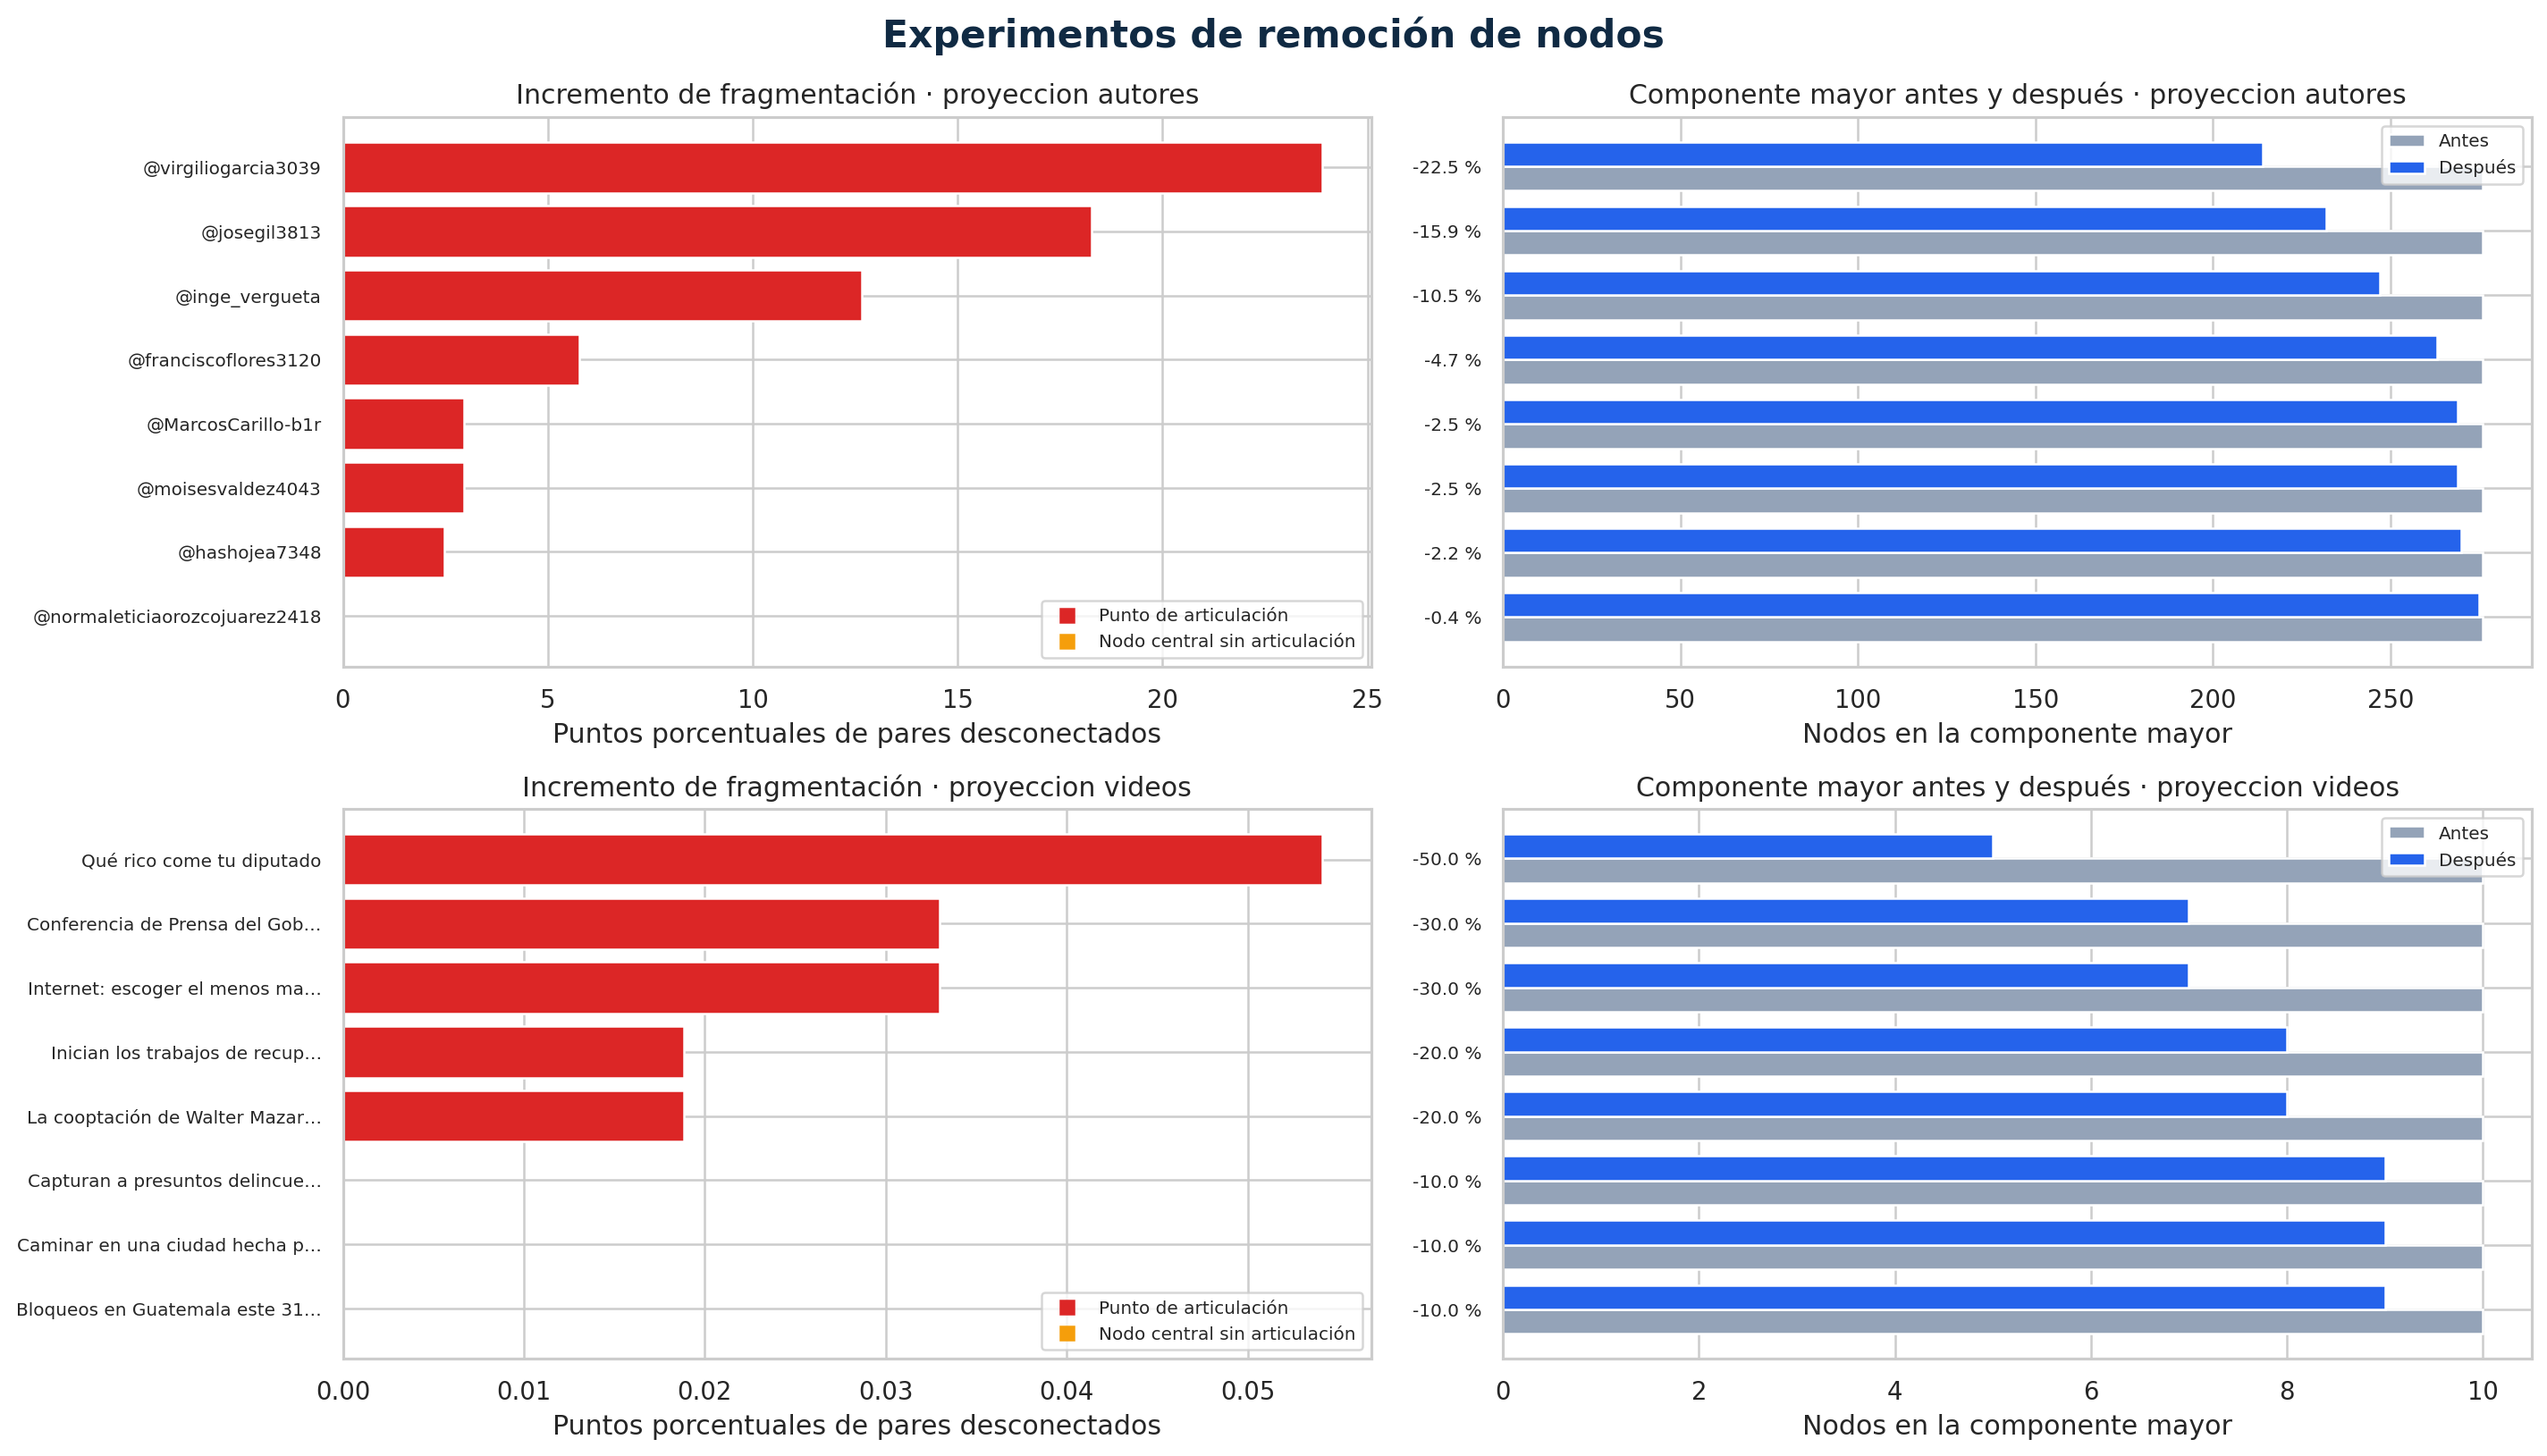

In [6]:
display(pd.read_csv(TABLES / "componentes_redes.csv").groupby("red").head(5))
display(pd.read_csv(TABLES / "impacto_remocion.csv").head(12))
display(Image(filename=str(FIGURES / "impacto_remocion.png"), width=900))

La red video–video posee solo **10 videos conectados** y **283 aislados**. La proyección de autores tiene transitividad 0.984, agrupamiento ponderado 0.486 y conectividad de nodos/aristas 1/5 en su componente mayor; la de videos tiene transitividad 0.316, agrupamiento 0.006 y conectividad 1/1. De 25 nodos candidatos evaluados, 12 fragmentan sus respectivas proyecciones. La estructura es redundante dentro de camarillas, pero frágil en sus pocos enlaces entre videos.

<div class="section"><h2>7 · Comunidades</h2></div>

Se eligió la proyección autor–autor porque agrupa patrones de coparticipación y permite asociar directamente el contenido de los comentarios. Louvain maximiza modularidad usando como peso el número de videos compartidos; con semilla 42 identifica 10 comunidades (modularidad **0.395**). Cada grupo se caracteriza por autores, intensidad, términos, videos, canales, categorías, estructura interna y sentimiento. Cuatro autores aislados se conservan como grupo 0 y no se fuerzan dentro de una comunidad.

,community,authors,comments,videos,top_terms,sentimiento_dominante,pct_negativo,pct_neutral,pct_positivo,dependiente_de_pocos_nodos
0,1,126,161,3,"pueblo, dinero, diputados, trabajo, diputado, ...",negativo,80.745342,13.664596,5.590062,False
1,2,61,83,3,"presidente, guatemala, país, años, arevalo, ni...",negativo,44.578313,27.710843,27.710843,True
2,3,55,60,4,"usac, corruptos, universidad, estudiantes, inf...",negativo,61.666667,18.333333,20.000000,True
3,4,28,33,3,"excelente, empresas, solo, internet, ley, país...",negativo,51.515152,24.242424,24.242424,True
4,5,25,25,1,"guatemala, ciudad, saludos, todos, viva, proye...",positivo,8.000000,8.000000,84.000000,False
5,6,18,25,1,"you, usa, pais, otros, país, if, to, ver",negativo,68.000000,24.000000,8.000000,False
6,7,6,6,1,"asquerosos, gasolina, subira, guerra, países, ...",negativo,83.333333,16.666667,0.000000,False
7,8,4,4,1,"iniciativa, juego, excelente, ve, deporte, din...",positivo,25.000000,0.000000,75.000000,True
8,9,3,3,1,"guatemala, solo, cambia, dictadura, cada, años...",positivo,33.333333,0.000000,66.666667,True
9,10,2,2,1,"persona, encargada, ecosistema, ayude, problem...",negativo,50.000000,50.000000,0.000000,True


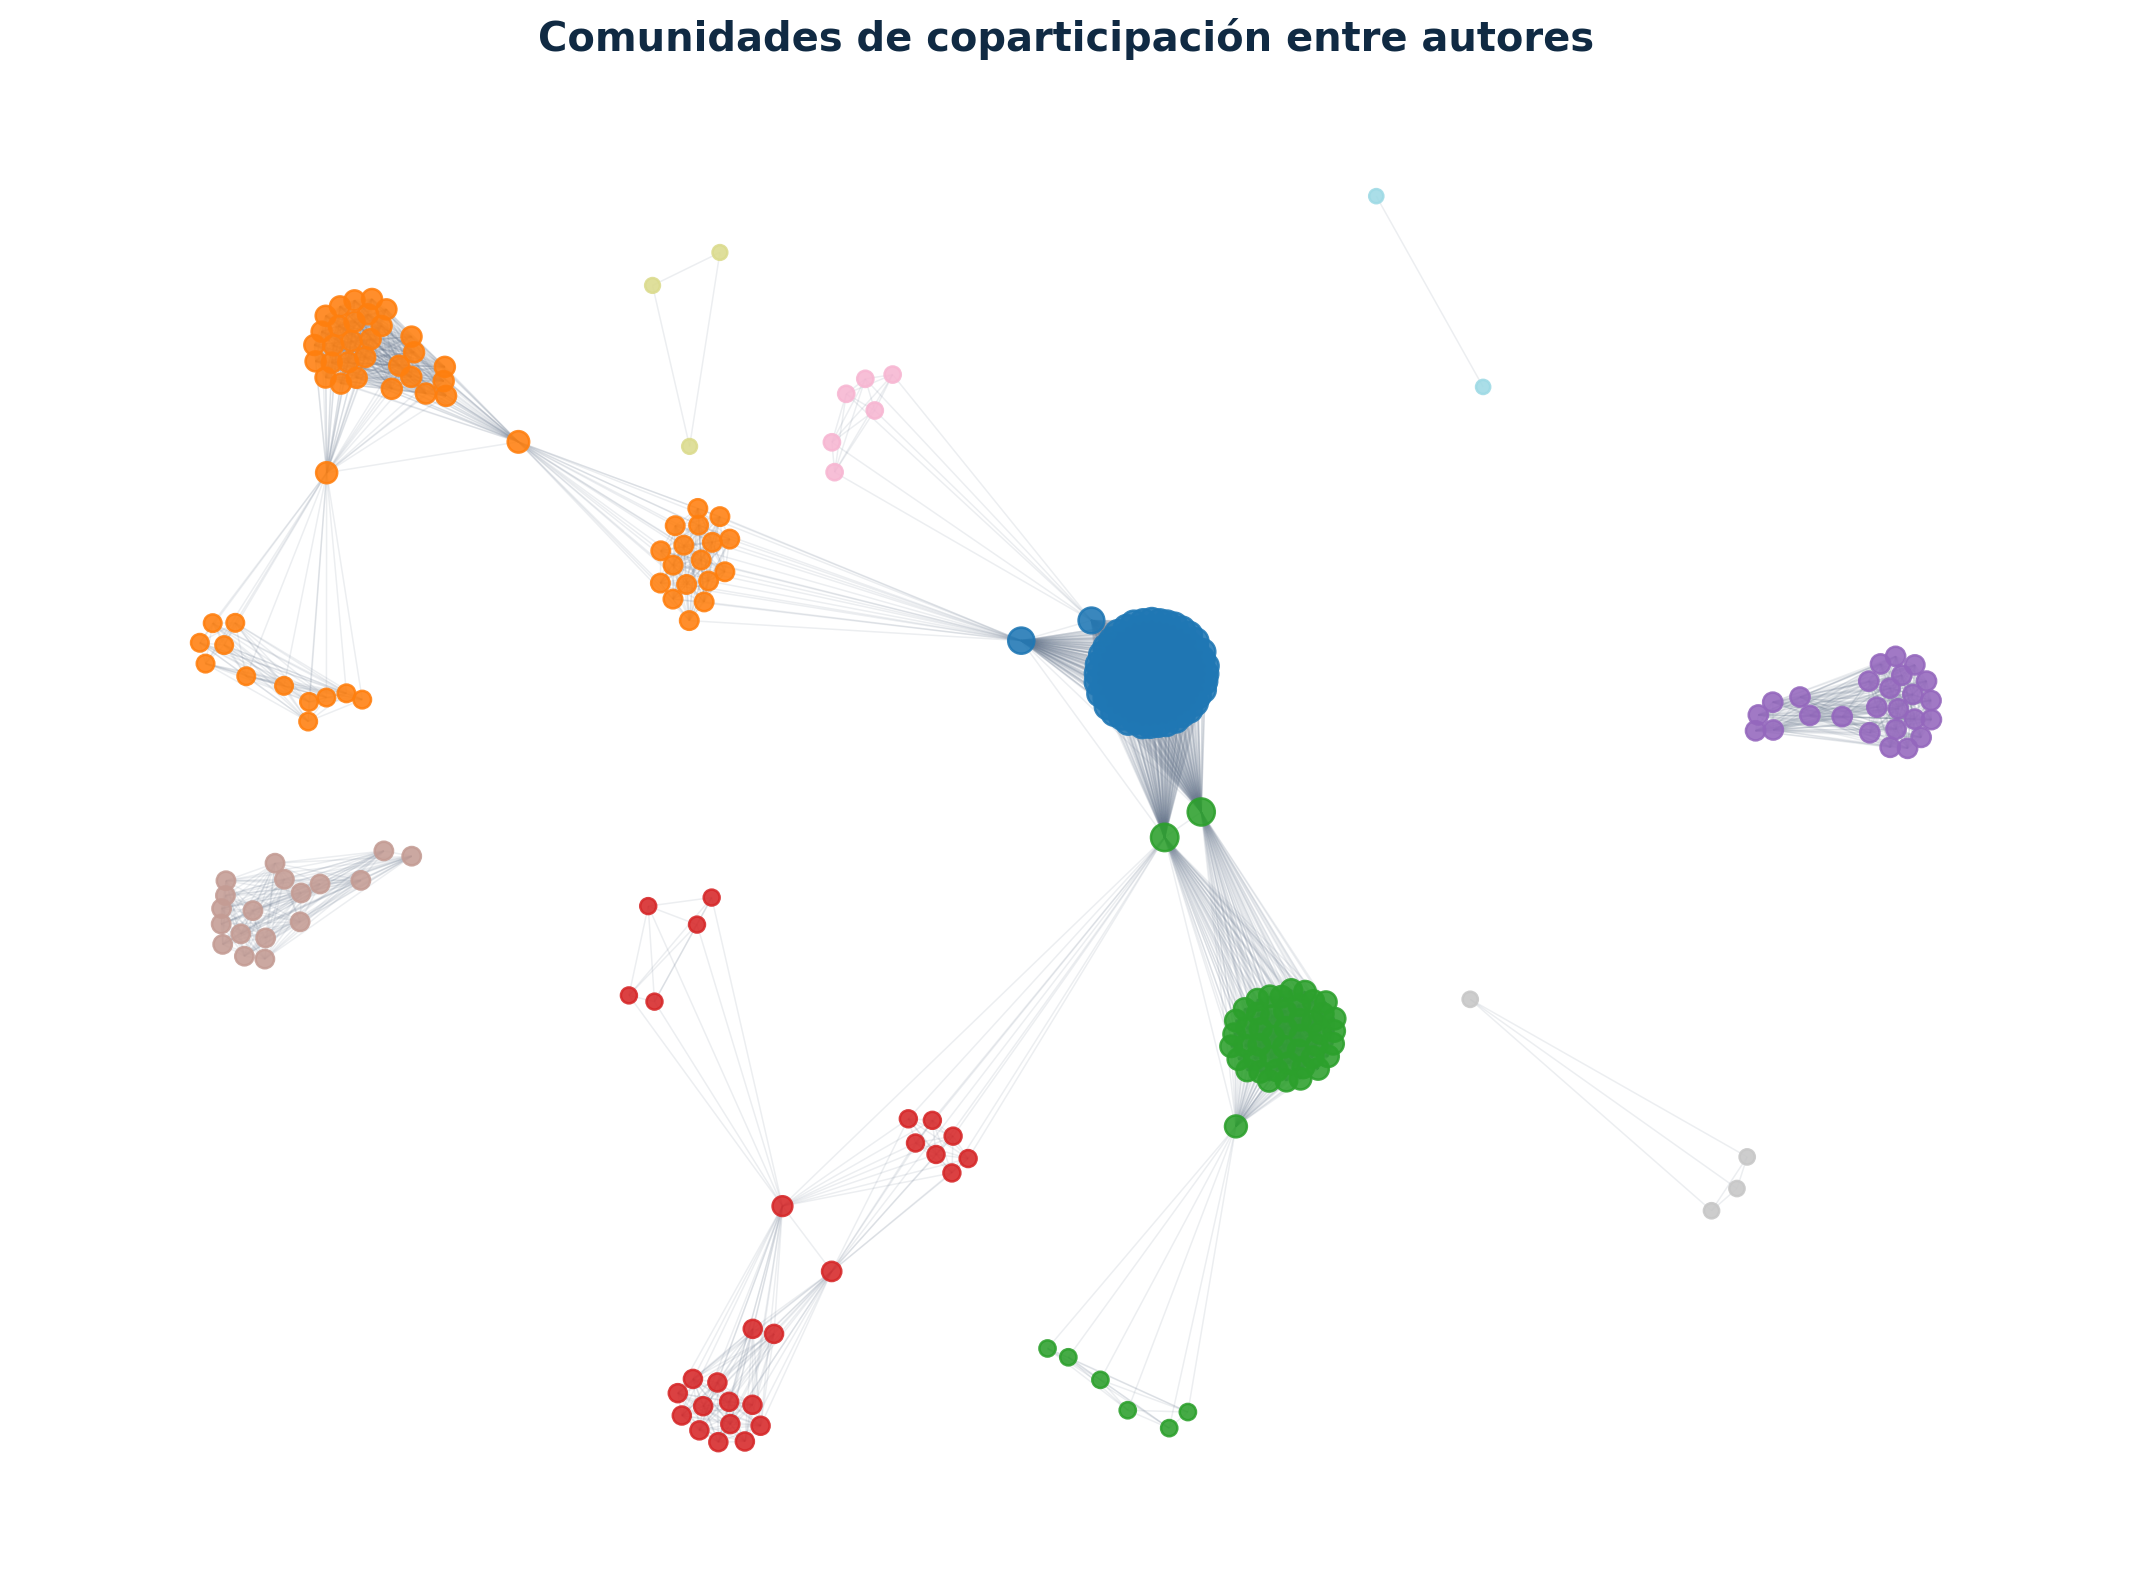

In [7]:
communities = pd.read_csv(TABLES / "comunidades_caracterizacion_final.csv")
display(communities[["community","authors","comments","videos","top_terms","sentimiento_dominante","pct_negativo","pct_neutral","pct_positivo","dependiente_de_pocos_nodos"]])
display(Image(filename=str(FIGURES / "comunidades_autores.png"), width=850))

**Tres comunidades principales.** C1 reúne 126 autores y 161 comentarios en tres videos/canales; predominan “pueblo”, “dinero” y “diputados”, con 80.7 % negativo. C2 contiene 61 autores y 83 comentarios alrededor de Gobierno/Noti7 y temas de presidencia/Guatemala; su distribución es 44.6 % negativa, 27.7 % neutral y 27.7 % positiva. C3 agrupa 55 autores y 60 comentarios, principalmente sobre USAC/corrupción en Quorum y TN23; alcanza 61.7 % negativo. C2 y C3 dependen de pocos nodos articuladores; C1 es internamente una camarilla densa.

<div class="section"><h2>8 · Centralidad, puentes y articuladores</h2></div>

Grado y grado ponderado reflejan alcance directo; intermediación identifica conexiones entre regiones; cercanía armónica funciona en redes desconectadas; PageRank ponderado combina cantidad y calidad de vecinos. Un puente estructural debe además ser punto de articulación y demostrar impacto al removerse.

,label,videos_comentados,intermediacion,es_punto_articulacion,tipo_puente
0,@virgiliogarcia3039,2,0.239019,True,puente estructural (su remoción fragmenta)
1,@inge_vergueta,3,0.220278,True,puente estructural (su remoción fragmenta)
2,@josegil3813,2,0.182660,True,puente estructural (su remoción fragmenta)
3,@franciscoflores3120,2,0.057786,True,puente estructural (su remoción fragmenta)
4,@hashojea7348,3,0.057402,True,puente estructural (su remoción fragmenta)
5,@MarcosCarillo-b1r,2,0.029552,True,puente estructural (su remoción fragmenta)
6,@moisesvaldez4043,2,0.029552,True,puente estructural (su remoción fragmenta)
7,@Jel.Awesh.M,2,0.093646,False,puente redundante (conecta con rutas alternati...
8,@Alejandro00710,2,0.032683,False,puente redundante (conecta con rutas alternati...


,label,videos_conectados,intermediacion,es_punto_articulacion,tipo_articulador
0,Qué rico come tu diputado,4,0.000541,True,articulador (su remoción segmenta la red)
1,Internet: escoger el menos malo,4,0.000330,True,articulador (su remoción segmenta la red)
2,Conferencia de Prensa del Gobierno de Guatemal...,2,0.000330,True,articulador (su remoción segmenta la red)
3,La cooptación de Walter Mazariegos en la USAC,3,0.000188,True,articulador (su remoción segmenta la red)
4,Inician los trabajos de recuperación del Puent...,2,0.000188,True,articulador (su remoción segmenta la red)


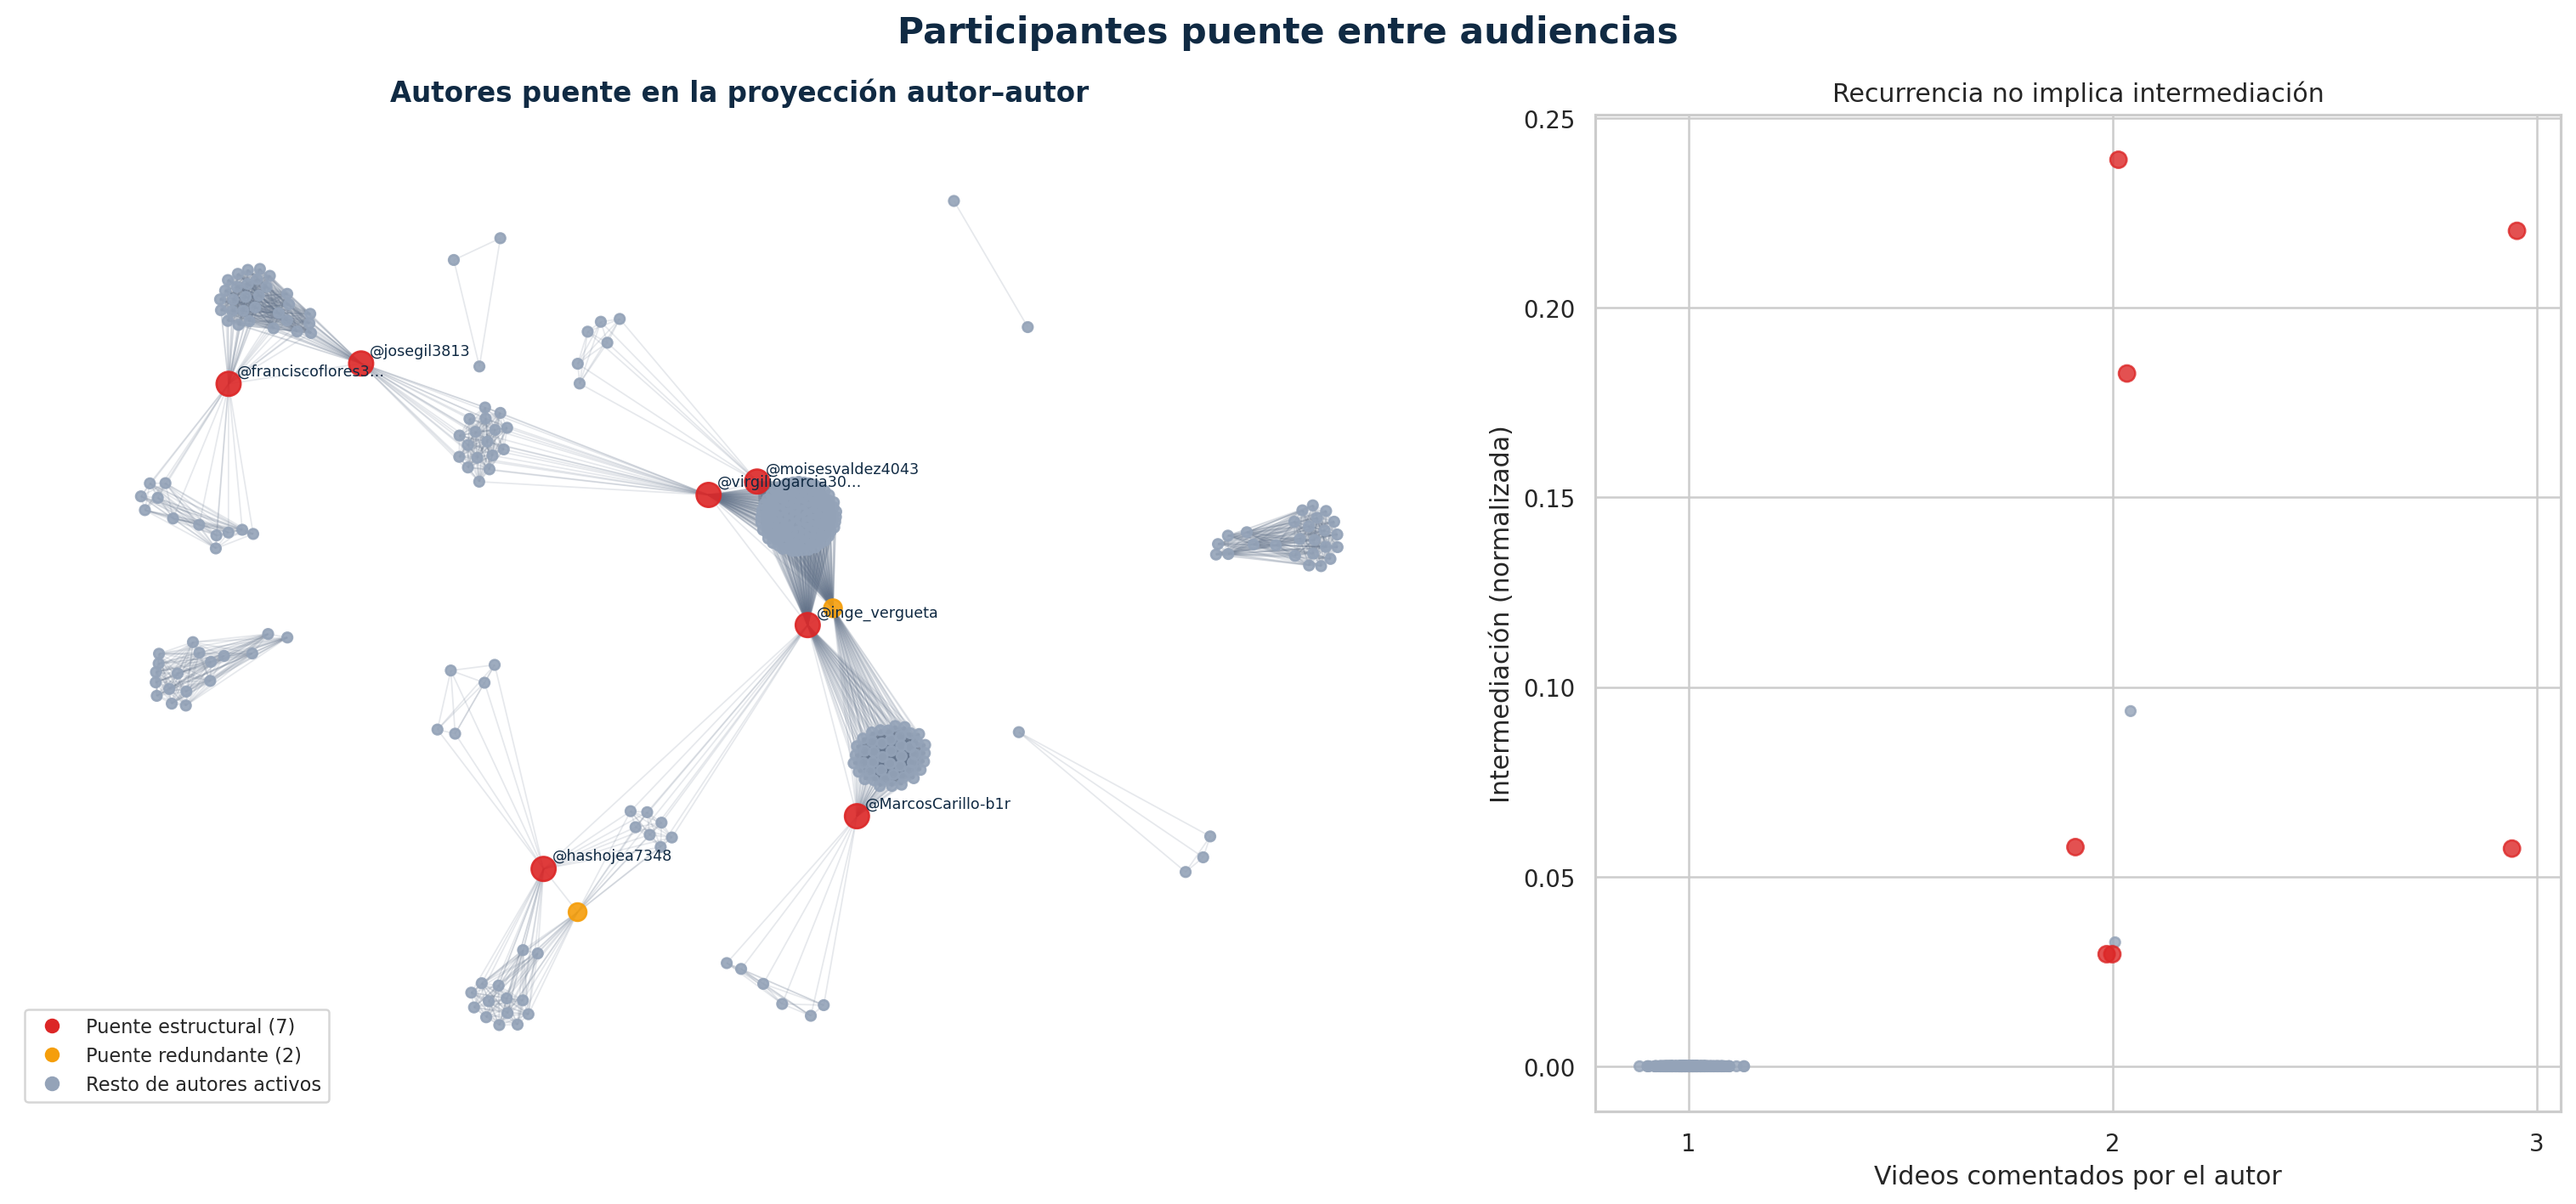

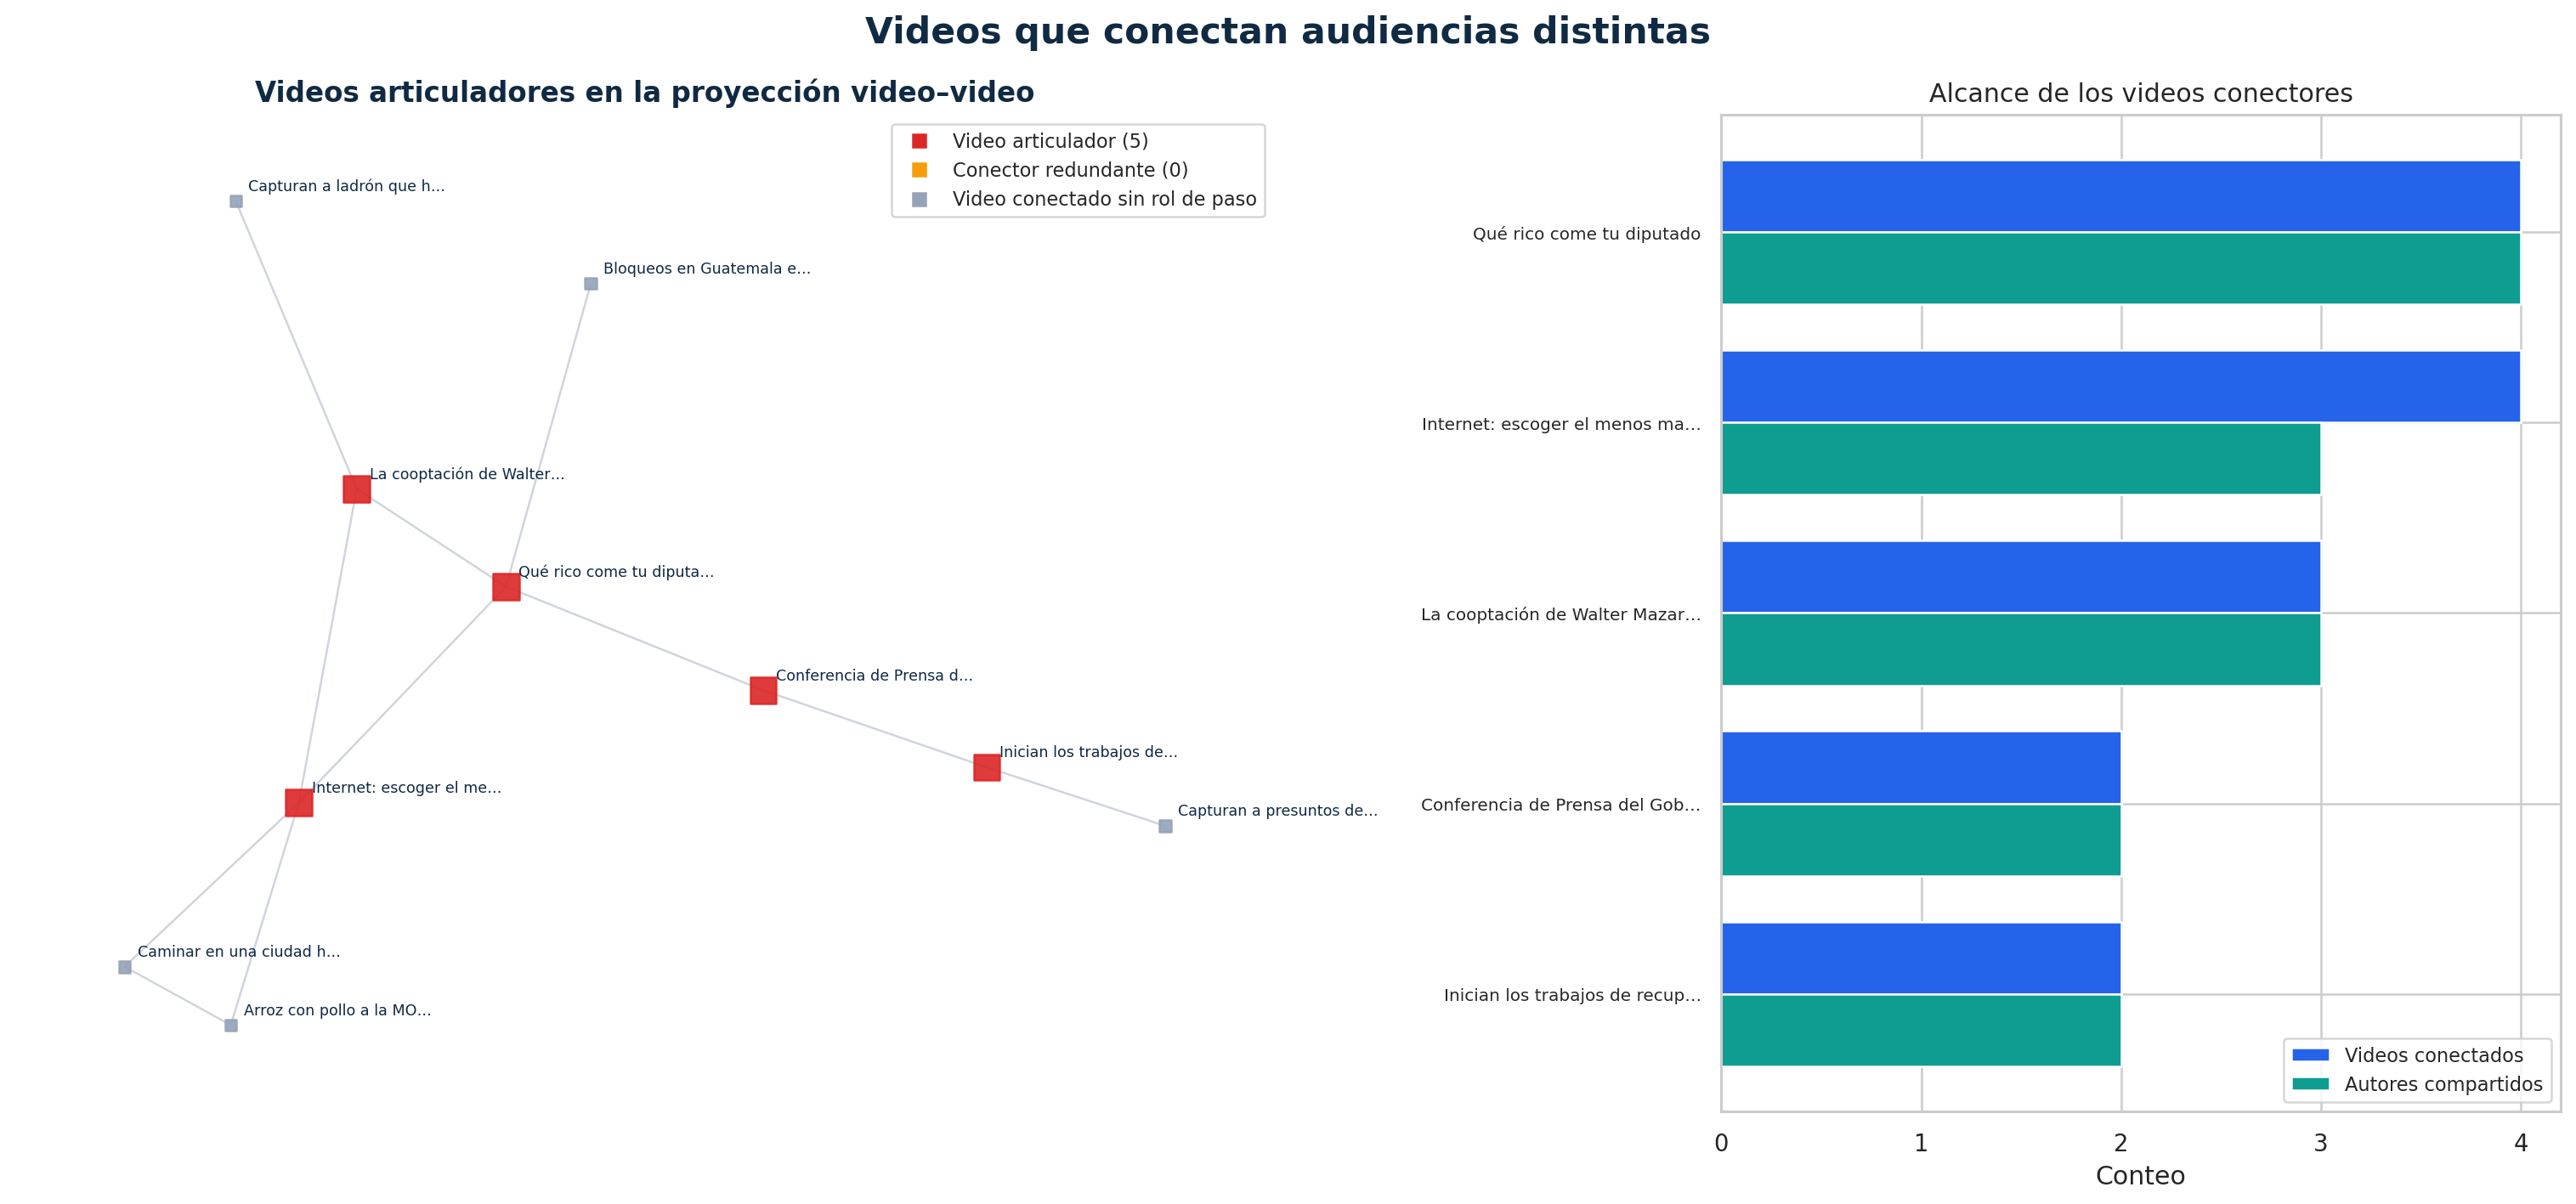

In [8]:
authors = pd.read_csv(TABLES / "autores_puente.csv")
videos = pd.read_csv(TABLES / "videos_articuladores.csv")
display(authors[["label","videos_comentados","intermediacion","es_punto_articulacion","tipo_puente"]])
display(videos[["label","videos_conectados","intermediacion","es_punto_articulacion","tipo_articulador"]])
display(Image(filename=str(FIGURES / "autores_puente.png"), width=880))
display(Image(filename=str(FIGURES / "videos_articuladores.png"), width=880))

Se hallaron **7 autores puente estructurales** y **5 videos articuladores**. La recurrencia es necesaria para conectar videos, pero no basta: importa cuáles camarillas une cada autor y si existen rutas alternativas.

<div class="section"><h2>9 · Contenido y sentimiento en español</h2></div>

Se emplea `pysentimiento/robertuito-sentiment-analysis`, modelo para texto social en español con etiquetas NEG/NEU/POS. Se guardan las tres probabilidades, la clase, confianza, margen, revisión del modelo y huella SHA-256 del texto. Una caché solo se reutiliza si coinciden modelo, IDs y textos.

,grupo,n_comentarios,negativos,neutrales,positivos,prob_negativo_media,prob_neutral_media,prob_positivo_media,confianza_media,baja_confianza_n,pct_negativo,pct_neutral,pct_positivo,sentimiento_dominante,muestra_interpretable,minimo_muestra
0,general,406,249,75,82,0.5761,0.212009,0.211891,0.818494,61,61.330049,18.472906,20.197044,negativo,True,5


,nivel_confianza,comentarios,porcentaje
0,baja (<0.60),61,15.024631
1,media (0.60–0.80),89,21.921182
2,alta (>0.80),256,63.054187


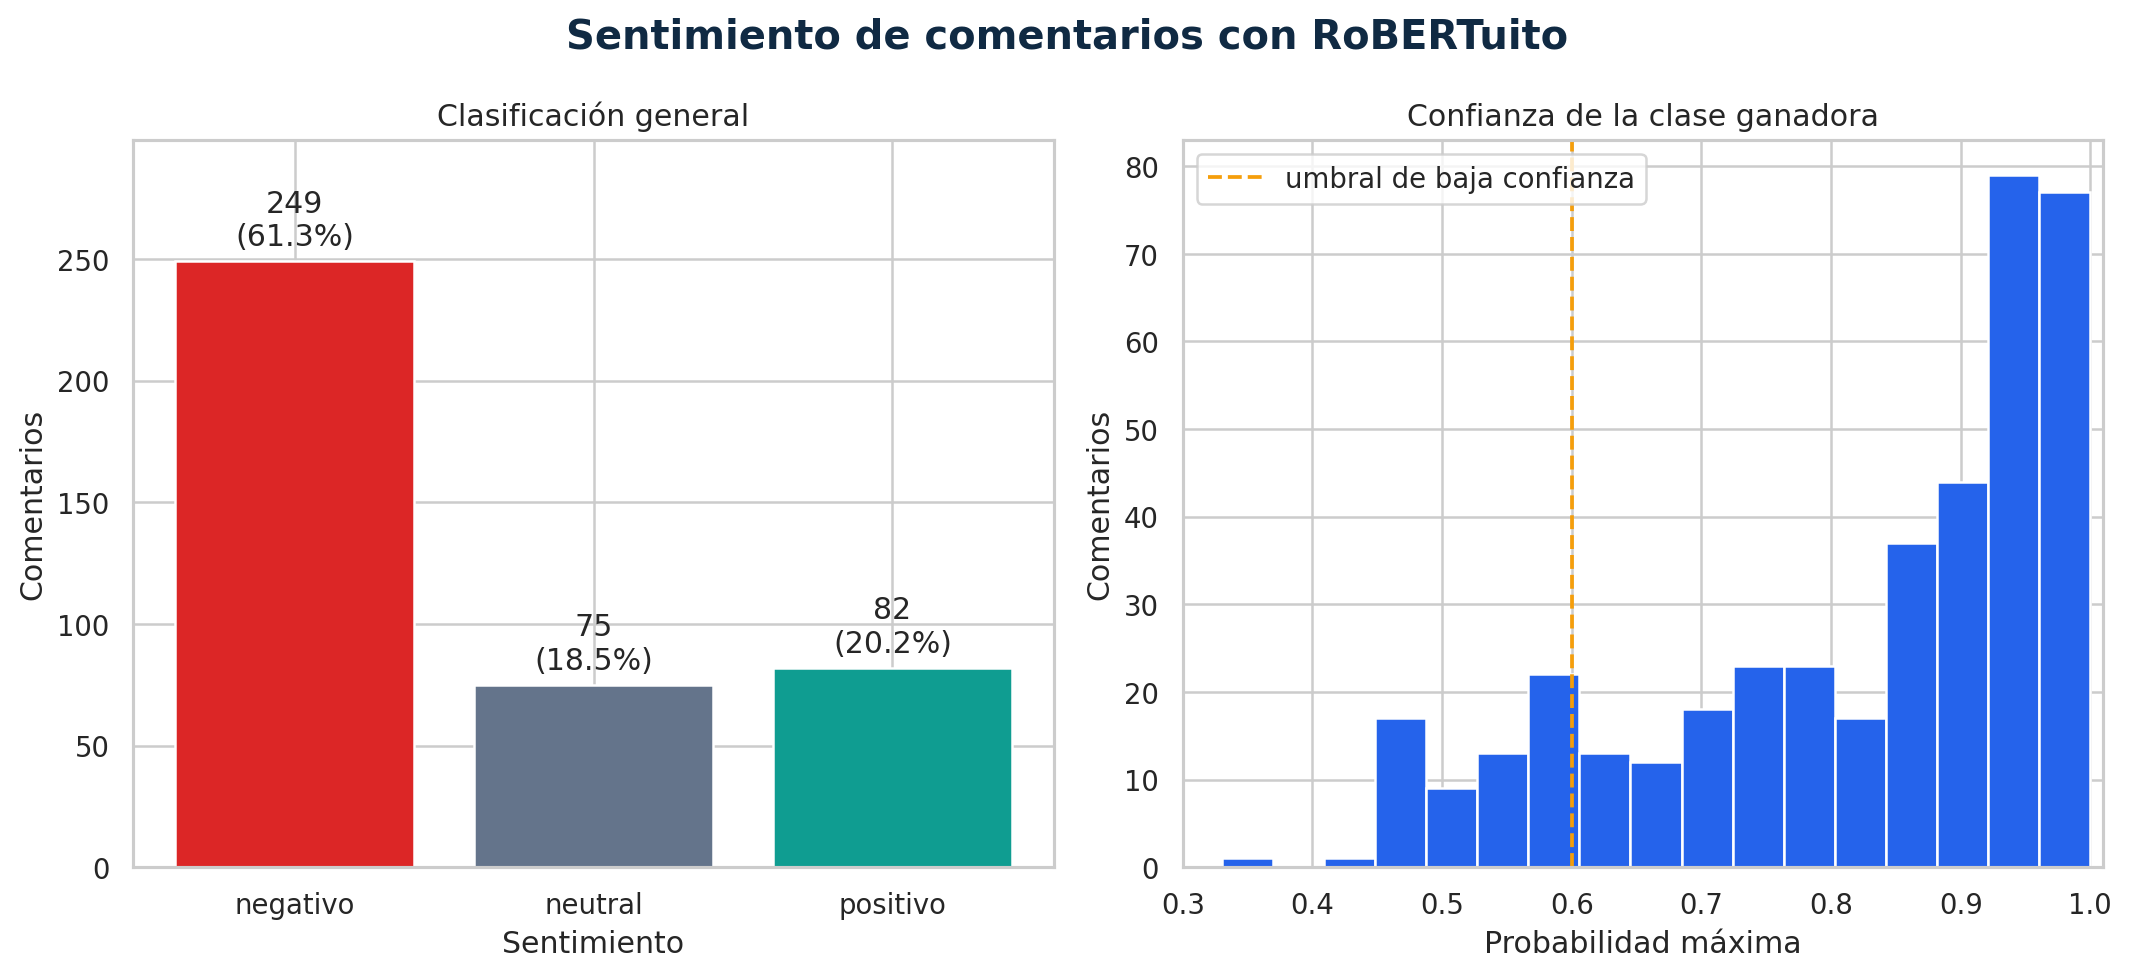

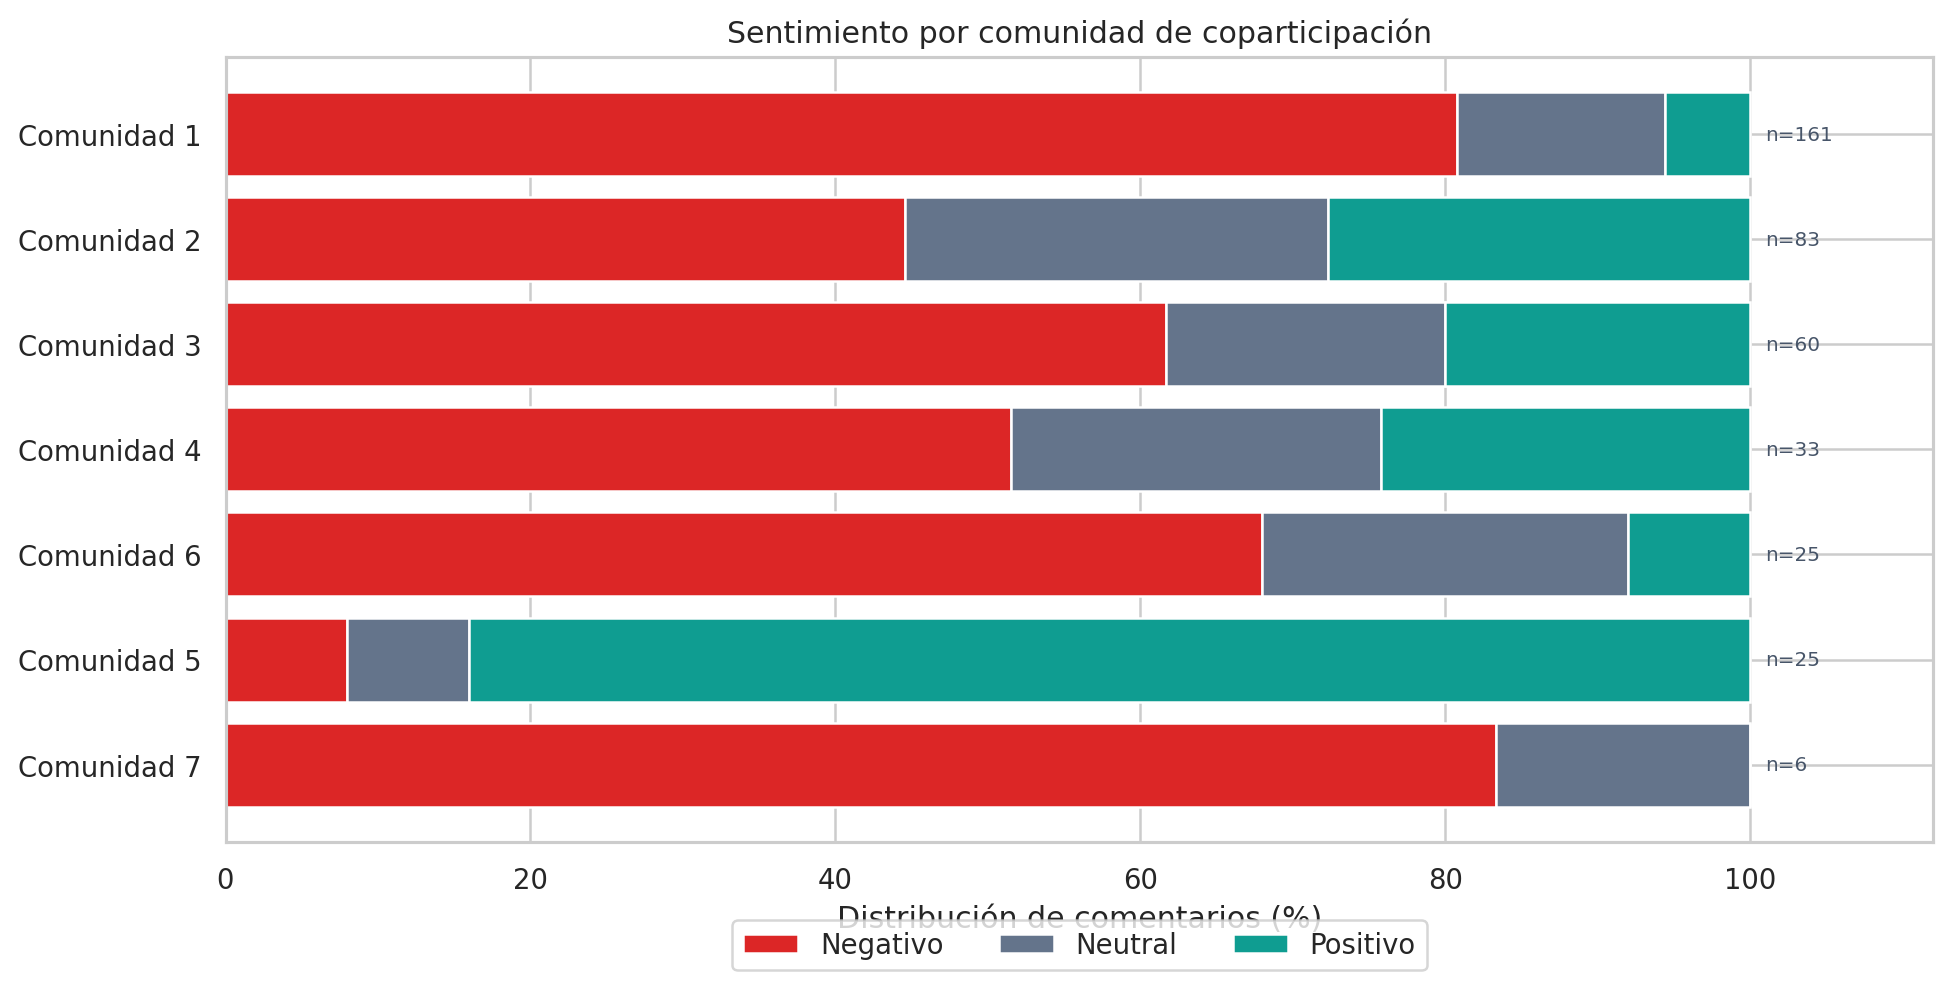

In [9]:
general = pd.read_csv(TABLES / "sentimiento_general.csv")
confidence = pd.read_csv(TABLES / "sentimiento_confianza.csv")
display(general)
display(confidence)
display(Image(filename=str(FIGURES / "sentimiento_panorama.png"), width=900))
display(Image(filename=str(FIGURES / "sentimiento_por_comunidad.png"), width=900))

El corpus es **61.3 % negativo, 18.5 % neutral y 20.2 % positivo**. La confianza media es 0.818; 61 comentarios (15.0 %) quedan bajo 0.60. Las comparaciones por grupo solo se interpretan formalmente con al menos cinco comentarios. La comunidad 5 contrasta con el patrón general: 84.0 % positivo (n=25).

<div class="warn"><b>Cautela:</b> una etiqueta automática no equivale a emoción verificada. Ironía, jerga, contexto político y mezcla lingüística pueden causar errores. Por eso se reportan probabilidades y confianza, y no solo la clase ganadora.</div>

<div class="section"><h2>10 · Síntesis, limitaciones y conclusiones</h2></div>

In [10]:
display(pd.read_csv(TABLES / "preguntas_obligatorias.csv"))
display(pd.read_csv(TABLES / "conclusiones_finales.csv"))
display(pd.read_csv(TABLES / "limitaciones_finales.csv"))

,pregunta,evidencia
0,¿Qué videos y canales concentran la mayor part...,El video líder es 'Qué rico come tu diputado' ...
1,¿Existen audiencias compartidas?,"Sí, aunque son escasas: 9 autores aparecen en ..."
2,¿Qué autores funcionan como puentes?,Se identificaron 7 puentes estructurales media...
3,¿Qué temas y sentimientos caracterizan las com...,"Las 10 comunidades se describen por términos, ..."
4,¿Qué videos articulan audiencias?,Hay 5 videos que son puntos de articulación: Q...
5,¿Qué ocurre al remover nodos centrales?,"De 25 nodos evaluados, 12 aumentan el número d..."
6,¿Cuál es el sentimiento general?,"Predomina negativo: 61.3 % negativo, 18.5 % ne..."
7,¿Qué limita las conclusiones?,Solo 19 de 293 videos tienen comentarios; la m...


,hallazgo,conclusion
0,Participación concentrada,El top 5 de videos reúne 75.4 % de comentarios...
1,Red fragmentada,Solo 10 de 293 videos se conectan mediante aut...
2,Puentes escasos,Los 7 autores articuladores sostienen conexion...
3,Comunidades interpretables,Los grupos se caracterizaron conjuntamente por...
4,Sentimiento,"La etiqueta general dominante es negativo, per..."
5,Alcance,Los resultados describen el corpus entregado y...


,limitacion,implicacion,mitigacion
0,Cobertura de comentarios,Hay comentarios para 19 de 293 videos.,Reportar explícitamente ceros y separar ausenc...
1,Muestreo por consultas,Los temas dependen de las búsquedas que origin...,Conservar source_query/source_group y restring...
2,Identidad observable,Un canal de autor no equivale necesariamente a...,Usar author_channel_id como nodo estable y nom...
3,Respuestas,"reply_count es un conteo, sin autores ni texto...",No crear aristas de respuesta; analizar únicam...
4,Sentimiento automático,"Ironía, jerga, código mixto y contexto polític...","Modelo español para texto social, probabilidad..."
5,Instantánea temporal,"Vistas, likes y comentarios cambian después de...",Tratar métricas como corte temporal y evitar c...


La evidencia describe el corpus entregado, no a toda la audiencia guatemalteca de YouTube. La cobertura parcial, el muestreo por consultas y el carácter temporal de vistas/likes limitan la generalización. Aun así, la combinación de topología, remoción, comunidades, contenido y sentimiento permite distinguir participación masiva de conexión estructural.

<div class="section"><h2>Auditoría de la rúbrica</h2></div>

In [11]:
rubric = pd.read_csv(TABLES / "cumplimiento_rubrica_final.csv")
display(rubric)
print(f"Cobertura documentada: {rubric.puntos_cubiertos.sum()}/{rubric.puntos.sum()} puntos")
assert rubric.puntos_cubiertos.sum() == rubric.puntos.sum() == 100

,criterio,puntos,estado,evidencia,puntos_cubiertos
0,"Calidad, limpieza y preprocesamiento",18,completo,calidad_resumen.csv; auditoria_limpieza_texto....,18
1,Análisis exploratorio,18,completo,participacion_por_video.csv; frecuencias; conc...,18
2,Red bipartita autor-video,10,completo,nodos_bipartita.csv; aristas_bipartita.csv; re...,10
3,Proyecciones,8,completo,aristas_autores.csv; aristas_videos.csv; ambas...,8
4,Topología y fragmentación,12,completo,metricas_redes.csv; componentes; impacto_remoc...,12
5,Comunidades,10,completo,comunidades_caracterizacion_final.csv; comunid...,10
6,Nodos centrales y participantes puente,7,completo,centralidad_autores.csv; autores_puente.csv; p...,7
7,Contenido y sentimiento,5,completo,sentimiento_comentarios.csv; agregaciones; fig...,5
8,"Interpretación, limitaciones y conclusiones",12,completo,preguntas_obligatorias.csv; conclusiones_final...,12


Cobertura documentada: 100/100 puntos


<div class="note"><b>Reproducibilidad:</b> ejecute <code>python scripts/run_final.py</code> para reconstruir tablas y figuras. Use <code>LAB6_FORCE_SENTIMENT=1</code> únicamente si desea repetir la inferencia en vez de reutilizar la caché validada.</div>